In [17]:
#!pip install torch numpy pandas matplotlib scipy scikit-learn dill plotly

In [18]:
#!pip install -r /Users/20s_a02/repositories/EPDE/requirements.txt


In [ ]:
import numpy as np
import pandas as pd
import dill as pickle
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import epde
import optuna
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances)
import json
from epde import EpdeSearch
import re
import itertools
from pathlib import Path
from typing import List, Dict, Tuple, Any

In [ ]:
# ==========================
# === DATA PROCESSOR CLASS ===
# ==========================
class DataProcessor:
    """
    Handles raw data extraction and normalization.

    Attributes
    ----------
    data : List
        Raw input data.
    coord_data : dict
        Dictionary storing coordinates per object.
    angle_data : dict
        Dictionary storing angle values per object.
    normalized_coord_data : dict
        Dictionary storing normalized coordinates.
    """
    def __init__(self, data: List):
        self.data = data
        self.coord_data = {}
        self.angle_data = {}
        self.normalized_coord_data = {}

    # === Data extraction ===
    def extract_data(self) -> Tuple[Dict, Dict]:
        """Extracts coordinate and angle data from raw input."""
        coord_data = {}
        angle_data = {}

        for inner_list in self.data:
            for item in inner_list:
                key = item[0]
                angle = np.deg2rad(item[1]) 
                coordinates = item[2]

                if key not in coord_data:
                    coord_data[key] = []
                    angle_data[key] = []

                coord_data[key].append(coordinates)
                angle_data[key].append(angle)

        self.coord_data = coord_data
        self.angle_data = angle_data
        return coord_data, angle_data

    # === Normalization ===
    @staticmethod
    def normalize_to_normal_distribution(data: np.ndarray) -> np.ndarray:
        """Applies Box-Cox transformation and MinMax scaling to [0,1]."""
        if np.min(data) <= 0:
            data = data - np.min(data) + 1e-6
        transformed_data, _ = stats.boxcox(data)
        scaler = MinMaxScaler(feature_range=(0, 1))
        normalized_data = scaler.fit_transform(transformed_data.reshape(-1, 1)).flatten()
        return normalized_data

    def normalize_all_coordinates(self) -> Dict:
        """Normalizes all coordinates of all objects."""
        all_x, all_y = [], []
        
        for points in self.coord_data.values():
            points_array = np.array(points)
            all_x.extend(points_array[:, 0])
            all_y.extend(points_array[:, 1])

        x_normalized = self.normalize_to_normal_distribution(np.array(all_x))
        y_normalized = self.normalize_to_normal_distribution(np.array(all_y))
        
        idx = 0
        for obj_id, points in self.coord_data.items():
            points_array = np.array(points)
            num_points = len(points_array)
            obj_x_norm = x_normalized[idx:idx + num_points]
            obj_y_norm = y_normalized[idx:idx + num_points]
            self.normalized_coord_data[obj_id] = np.column_stack((obj_x_norm, obj_y_norm))
            idx += num_points

        return self.normalized_coord_data


In [ ]:
# ==========================
# === EQUATION DISCOVERER CLASS ===
# ==========================
class EquationDiscoverer:
    """
    Wrapper for EPDE search for discovering system equations.

    Attributes
    ----------
    samples : list
        Input data (normalized coordinates or signals).
    """
    def __init__(self, samples: list):
        self._samples = samples

    # === Discover system equations ===
    def discover_system_equation(self, epde_search_obj: EpdeSearch,
                                 additional_tokens: List, dimensionality: int = 0) -> Any:
        """Performs EPDE search for system of equations."""
        factors_max_number = {'factors_num': [1, 2], 'probas': [0.85, 0.15]}
        
        trig_tokens = epde.TrigonometricTokens(freq=(0.999, 1.001), dimensionality=dimensionality)
        grid_tokens = epde.GridTokens(['t'], dimensionality=dimensionality)
        
        epde_search_obj.fit(
            data=self._samples,
            variable_names=['x', 'y'],
            max_deriv_order=2,
            equation_terms_max_number=3,
            data_fun_pow=1,
            additional_tokens=additional_tokens+[trig_tokens, grid_tokens],
            equation_factors_max_number=factors_max_number,
            eq_sparsity_interval=(1e-10, 1)
        )

        return epde_search_obj.equations(only_print=False, only_str=False, num=2)


In [ ]:
# ==========================
# === EQUATION PROCESSOR CLASS ===
# ==========================
class EquationProcessor:
    """
    Processes EPDE-discovered equations into structured tables for analysis.

    Attributes
    ----------
    regex : compiled regex
        Used to remove frequency patterns from term names.
    """

    def __init__(self):
        self.regex = re.compile(r', freq:\s\d\S\d+')

    # === Helper to update dictionaries ===
    @staticmethod
    def dict_update(d_main: Dict, term: str, coeff: float, k: int) -> Dict:
        """Updates dictionary of terms with new coefficients."""
        str_t = '_r' if '_r' in term else ''
        arr_term = re.sub('_r', '', term).split(' * ')
        perm_set = list(itertools.permutations(range(len(arr_term))))
        structure_added = False

        for p_i in perm_set:
            temp = " * ".join([arr_term[i] for i in p_i]) + str_t
            if temp in d_main:
                if k - len(d_main[temp]) >= 0:
                    d_main[temp] += [0 for _ in range(k - len(d_main[temp]))] + [coeff]
                else:
                    d_main[temp][-1] += coeff
                structure_added = True

        if not structure_added:
            d_main[term] = [0 for _ in range(k)] + [coeff]

        return d_main

   # === Convert equation to table ===
    def equation_table(self, k: int, equation, dict_main: Dict, dict_right: Dict) -> List[Dict]:
        """Creates structured dictionary from EPDE equation."""
        equation_s = equation.structure
        equation_c = equation.weights_final
        text_form_eq = self.regex.sub('', equation.text_form)

        flag = False
        for t_eq in equation_s:
            term = self.regex.sub('', t_eq.name)
            for t in range(len(equation_c)):
                c = equation_c[t]
                if f'{c} * {term} +' in text_form_eq:
                    dict_main = self.dict_update(dict_main, term, c, k)
                    equation_c = np.delete(equation_c, t)
                    break
                elif f'+ {c} =' in text_form_eq:
                    dict_main = self.dict_update(dict_main, "C", c, k)
                    equation_c = np.delete(equation_c, t)
                    break
            if f'= {term}' == text_form_eq[text_form_eq.find('='):] and not flag:
                flag = True
                dict_main = self.dict_update(dict_main, term, -1., k)

        return [dict_main, dict_right]

    # === Convert all objects to table ===
    def object_table(self, res: List, variable_names: List[str],
                     table_main: List[Dict], k: int) -> Tuple[List[Dict], int]:
        """Processes EPDE results into table format."""


        for list_SoEq in res:
            for SoEq in list_SoEq:
                for n, value in enumerate(variable_names):
                    gene = SoEq.vals.chromosome.get(value)
                    table_main[n][value] = self.equation_table(
                        k, gene.value, *table_main[n][value]
                    )
                k += 1
        return table_main, k

    # === Preprocess to DataFrame ===
    def preprocessing_table(self, variable_name: List[str],
                            table_main: List[Dict], k: int) -> pd.DataFrame:
        """Prepares final DataFrame from processed equation tables."""
        data_frame_total = pd.DataFrame()
        for dict_var in table_main:
            for var_name, list_structure in dict_var.items():
                general_dict = {}
                for structure in list_structure:
                    general_dict.update(structure)
                dict_var[var_name] = general_dict

        for dict_var in table_main:
            for var_name, general_dict in dict_var.items():
                for key, value in general_dict.items():
                    if len(value) < k:
                        general_dict[key] = value + [0. for _ in range(k - len(value))]

        data_frame_main = [{i: pd.DataFrame()} for i in variable_name]
        for n, dict_var in enumerate(table_main):
            for var_name, general_dict in dict_var.items():
                data_frame_main[n][var_name] = pd.DataFrame(general_dict)

        for n, var_name in enumerate(variable_name):
            data_frame_temp = data_frame_main[n].get(var_name).copy()
            list_columns = [f'{col}_{var_name}' for col in data_frame_temp.columns]
            data_frame_temp.columns = list_columns
            data_frame_total = pd.concat([data_frame_total, data_frame_temp], axis=1)

        return data_frame_total



[I 2026-01-16 00:55:52,304] A new study created in memory with name: no-name-8fd0fd07-19b9-40b3-840e-be3d00df1a03



 Processing robot 78 with 4 parts...

--- Optimizing part 1/4 (0:687) ---
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31f6c8c90>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31f6c8c90>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [1.76719912e-10 9.32116228e-02]
New solution accepted, confirmed 1/5 solutions.
Creating new equation, sparsity value [5.27786072e-02 1.73209043e-08]
New solution accepted, confirmed 2/5 solutions.
Creating new equation, sparsity valu

[I 2026-01-16 00:56:05,696] Trial 0 finished with value: 5.191736383166692 and parameters: {'poly_window': 9, 'population_size': 5, 'sigma': 60, 'boundary': 7}. Best is trial 0 with value: 5.191736383166692.


During MO : processing 4-th weight.
The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3300fa450>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3300fa450>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [8.65897063e-10 1.59933470e-07]
New solution accepted, confirmed 1/4 solutions.
Creating new equation, sparsity value [4.15970703e-08 9.02672514e-01]
New solution accepted, confirmed 2/4 solutions.
Creating new equation, 

[I 2026-01-16 00:56:16,614] Trial 1 finished with value: 5.635980506949738 and parameters: {'poly_window': 7, 'population_size': 4, 'sigma': 55, 'boundary': 5}. Best is trial 0 with value: 5.191736383166692.


...

[I 2026-01-16 01:02:22,045] Trial 18 finished with value: 2.621860205237905 and parameters: {'poly_window': 9, 'population_size': 7, 'sigma': 55, 'boundary': 5}. Best is trial 14 with value: 1.606104190634824.


During MO : processing 6-th weight.
The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31fafa690>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31fafa690>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [1.85346588e-01 3.15471951e-10]
New solution accepted, confirmed 1/6 solutions.
Creating new equation, sparsity value [4.35136408e-03 5.77949488e-06]
New solution accepted, confirmed 2/6 solutions.
Creating new equation, 

[I 2026-01-16 01:02:34,724] Trial 19 finished with value: 4.774507168116639 and parameters: {'poly_window': 5, 'population_size': 6, 'sigma': 60, 'boundary': 4}. Best is trial 14 with value: 1.606104190634824.


During MO : processing 4-th weight.
During MO : processing 5-th weight.
The optimization has been conducted.
✅ Trial finish
✅ Part 1: Best params {'poly_window': 5, 'population_size': 8, 'sigma': 65, 'boundary': 4}, score=1.606104190634824


setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31fb09410>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31fb09410>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [1.21521426e-02 7.91954341e-10]
New solution accepted, confirmed 1/8 solutions.
Creating new equation, sparsity value [6.88110427e-09 4.00946007e-05]
New solution accepted, confirmed 2/8 solutions.
Creating new equation, sparsity value [7.08116574e-10 5.62832479e-02]
New solution accepted, confirmed 3/8 solu

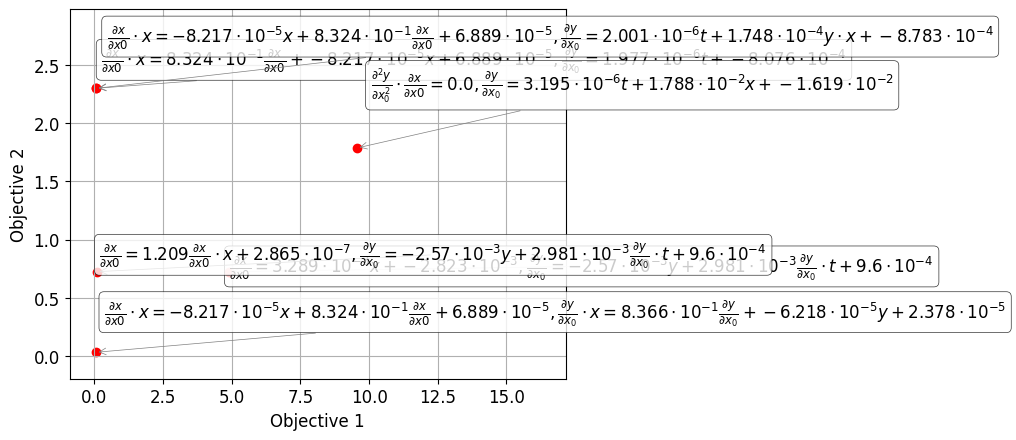

[I 2026-01-16 01:04:50,481] A new study created in memory with name: no-name-43c31e5a-4d79-418f-bb07-ff3f9f7c35ef



System of DE 1 (startpoint 0-686):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x31fec7890>, <epde.structure.main_structures.SoEq object at 0x330229290>, <epde.structure.main_structures.SoEq object at 0x341f55610>, <epde.structure.main_structures.SoEq object at 0x341e691d0>, <epde.structure.main_structures.SoEq object at 0x341e80410>, <epde.structure.main_structures.SoEq object at 0x3400a56d0>]
EQ 2:
[<epde.structure.main_structures.SoEq object at 0x33078e250>, <epde.structure.main_structures.SoEq object at 0x340088610>]
Saved: output/robot_78/4_parts/without_force/system_1.csv

--- Optimizing part 2/4 (687:1374) ---
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x330171210>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x330171210>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0]

[I 2026-01-16 01:05:02,711] Trial 0 finished with value: 6.656682166779165 and parameters: {'poly_window': 9, 'population_size': 4, 'sigma': 50, 'boundary': 6}. Best is trial 0 with value: 6.656682166779165.


The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31ff70a50>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31ff70a50>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [0.0005956  0.04767014]
New solution accepted, confirmed 1/8 solutions.
Creating new equation, sparsity value [9.10078466e-08 2.13974144e-06]
New solution accepted, confirmed 2/8 solutions.
Creating new equation, sparsity value [2.71198007e-01 5.17080259e-0

[I 2026-01-16 01:05:28,451] Trial 1 finished with value: 2.660300767028378 and parameters: {'poly_window': 5, 'population_size': 8, 'sigma': 45, 'boundary': 5}. Best is trial 1 with value: 2.660300767028378.


...

[I 2026-01-16 01:10:11,258] Trial 18 finished with value: 4.574481592297064 and parameters: {'poly_window': 9, 'population_size': 6, 'sigma': 50, 'boundary': 5}. Best is trial 12 with value: 2.6303698206686486.


During MO : processing 5-th weight.
The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3305b2390>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3305b2390>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [1.01156712e-05 2.76804534e-05]
New solution accepted, confirmed 1/8 solutions.
Creating new equation, sparsity value [2.61088589e-02 9.66814592e-05]
New solution accepted, confirmed 2/8 solutions.
Creating new equation, 

[I 2026-01-16 01:10:36,791] Trial 19 finished with value: 3.1988071076653566 and parameters: {'poly_window': 7, 'population_size': 8, 'sigma': 60, 'boundary': 4}. Best is trial 12 with value: 2.6303698206686486.


The optimization has been conducted.
✅ Trial finish
✅ Part 2: Best params {'poly_window': 11, 'population_size': 8, 'sigma': 65, 'boundary': 7}, score=2.6303698206686486


setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x330821410>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x330821410>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [1.0013945e-09 6.7492919e-08]
New solution accepted, confirmed 1/8 solutions.
Creating new equation, sparsity value [2.80759440e-06 9.10966964e-04]
New solution accepted, confirmed 2/8 solutions.
Creating new equation, sparsity value [0.00579231 0.04262913]
New solution accepted, confirmed 3/8 solutions.
Cre

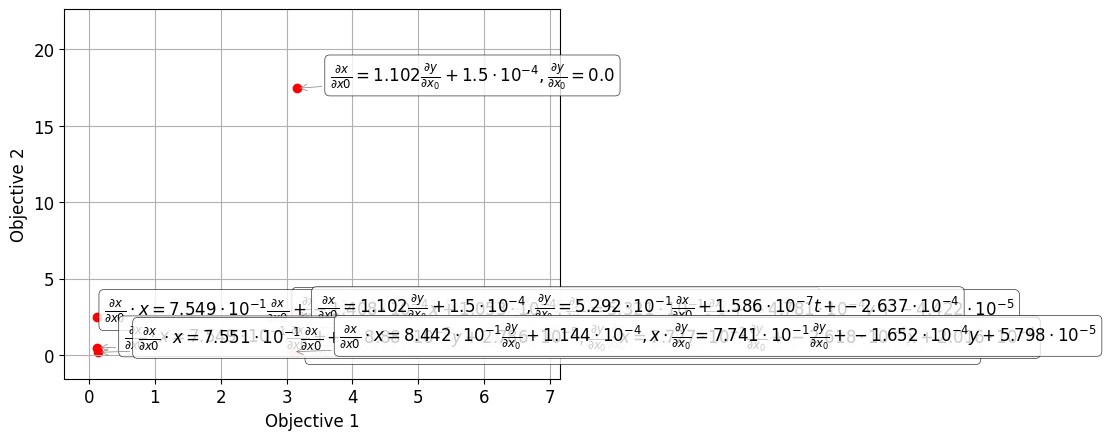

[I 2026-01-16 01:12:09,479] A new study created in memory with name: no-name-f3712af6-ee62-49bc-ac03-dacbcfe1c6ab



System of DE 2 (startpoint 687-1373):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x330867a50>, <epde.structure.main_structures.SoEq object at 0x3302dad50>, <epde.structure.main_structures.SoEq object at 0x3085172d0>, <epde.structure.main_structures.SoEq object at 0x31fae5190>, <epde.structure.main_structures.SoEq object at 0x3308d8c90>, <epde.structure.main_structures.SoEq object at 0x33098d290>, <epde.structure.main_structures.SoEq object at 0x31f988e50>, <epde.structure.main_structures.SoEq object at 0x31ffecad0>]
Saved: output/robot_78/4_parts/without_force/system_2.csv

--- Optimizing part 3/4 (1374:2061) ---
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x330e09410>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x330e09410>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [

[I 2026-01-16 01:12:27,555] Trial 0 finished with value: 5.289225512626309 and parameters: {'poly_window': 9, 'population_size': 7, 'sigma': 45, 'boundary': 5}. Best is trial 0 with value: 5.289225512626309.


The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31fd69410>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31fd69410>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [1.40388679e-07 3.04087502e-08]
New solution accepted, confirmed 1/4 solutions.
Creating new equation, sparsity value [1.07530095e-02 2.59749698e-09]
New solution accepted, confirmed 2/4 solutions.
Creating new equation, sparsity value [5.47229980e-07 4.969

[I 2026-01-16 01:12:38,103] Trial 1 finished with value: 4.683095909626439 and parameters: {'poly_window': 7, 'population_size': 4, 'sigma': 35, 'boundary': 6}. Best is trial 1 with value: 4.683095909626439.


...

[I 2026-01-16 01:17:00,116] Trial 18 finished with value: 4.454649587651331 and parameters: {'poly_window': 7, 'population_size': 7, 'sigma': 55, 'boundary': 4}. Best is trial 13 with value: 1.8163201734179169.


The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31fd69410>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31fd69410>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [2.39762810e-05 2.07662331e-04]
New solution accepted, confirmed 1/6 solutions.
Creating new equation, sparsity value [4.25589680e-08 3.80951071e-07]
New solution accepted, confirmed 2/6 solutions.
Creating new equation, sparsity value [5.37785808e-10 2.611

[I 2026-01-16 01:17:13,232] Trial 19 finished with value: 3.2046012512344118 and parameters: {'poly_window': 9, 'population_size': 6, 'sigma': 45, 'boundary': 6}. Best is trial 13 with value: 1.8163201734179169.


During MO : processing 5-th weight.
The optimization has been conducted.
✅ Trial finish
✅ Part 3: Best params {'poly_window': 7, 'population_size': 7, 'sigma': 55, 'boundary': 6}, score=1.8163201734179169


setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3305b1410>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3305b1410>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [9.19669574e-09 7.56137484e-07]
New solution accepted, confirmed 1/7 solutions.
Creating new equation, sparsity value [2.30509976e-07 3.83845695e-08]
New solution accepted, confirmed 2/7 solutions.
Creating new equation, sparsity value [1.65822064e-06 8.15107496e-04]
New solution accepted, confirmed 3/7 solu

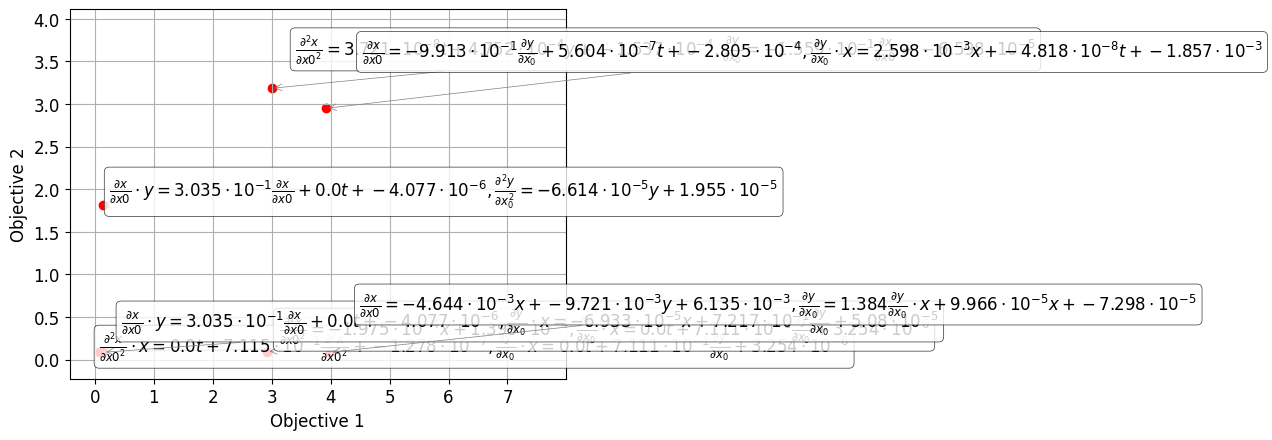

[I 2026-01-16 01:18:10,084] A new study created in memory with name: no-name-234559bd-619b-47bd-838a-25553bbc19af



System of DE 3 (startpoint 1374-2060):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x31f812a90>, <epde.structure.main_structures.SoEq object at 0x3401ef090>, <epde.structure.main_structures.SoEq object at 0x330b88ad0>, <epde.structure.main_structures.SoEq object at 0x331273750>, <epde.structure.main_structures.SoEq object at 0x330b76310>, <epde.structure.main_structures.SoEq object at 0x33125e850>, <epde.structure.main_structures.SoEq object at 0x341e330d0>]
Saved: output/robot_78/4_parts/without_force/system_3.csv

--- Optimizing part 4/4 (2061:2750) ---
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x330faa210>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x330faa210>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)

[I 2026-01-16 01:18:27,046] Trial 0 finished with value: 3.3697505895871602 and parameters: {'poly_window': 5, 'population_size': 7, 'sigma': 40, 'boundary': 6}. Best is trial 0 with value: 3.3697505895871602.


During MO : processing 5-th weight.
During MO : processing 6-th weight.
The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31f43b590>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31f43b590>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [2.05172210e-03 2.11966144e-09]
New solution accepted, confirmed 1/4 solutions.
Creating new equation, sparsity value [0.00032474 0.01688167]
New solution accepted, confirmed 2/4 soluti

[I 2026-01-16 01:18:38,319] Trial 1 finished with value: 7.005337811146962 and parameters: {'poly_window': 11, 'population_size': 4, 'sigma': 40, 'boundary': 6}. Best is trial 0 with value: 3.3697505895871602.


...

[I 2026-01-16 01:23:58,448] Trial 18 finished with value: 6.609787356912135 and parameters: {'poly_window': 11, 'population_size': 5, 'sigma': 35, 'boundary': 7}. Best is trial 7 with value: 0.2538802109378503.


During MO : processing 4-th weight.
The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31feef350>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31feef350>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [7.74211858e-05 8.43200420e-08]
New solution accepted, confirmed 1/8 solutions.
Creating new equation, sparsity value [4.23321420e-10 8.77396752e-03]
New solution accepted, confirmed 2/8 solutions.
Creating new equation, 

[I 2026-01-16 01:24:31,521] Trial 19 finished with value: 1.8240922068104573 and parameters: {'poly_window': 7, 'population_size': 8, 'sigma': 55, 'boundary': 4}. Best is trial 7 with value: 0.2538802109378503.


✅ Part 4: Best params {'poly_window': 5, 'population_size': 8, 'sigma': 40, 'boundary': 4}, score=0.2538802109378503


setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31f599410>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31f599410>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [0.00032185 0.00181475]
New solution accepted, confirmed 1/8 solutions.
Creating new equation, sparsity value [4.07588093e-01 1.38848901e-09]
New solution accepted, confirmed 2/8 solutions.
Creating new equation, sparsity value [0.21708318 0.00276248]
New solution accepted, confirmed 3/8 solutions.
Creating 

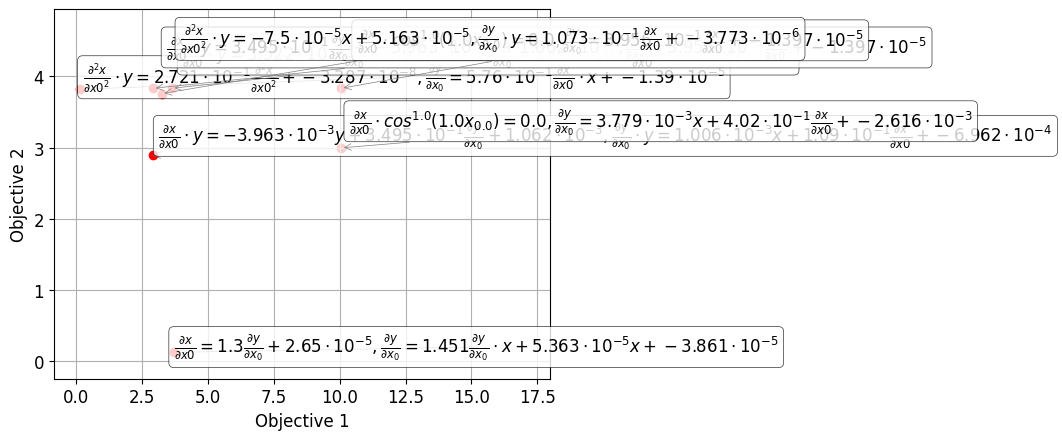


System of DE 4 (startpoint 2061-2749):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x31fe60290>, <epde.structure.main_structures.SoEq object at 0x330301a50>, <epde.structure.main_structures.SoEq object at 0x330c01690>, <epde.structure.main_structures.SoEq object at 0x3306f9310>, <epde.structure.main_structures.SoEq object at 0x341e4bc10>, <epde.structure.main_structures.SoEq object at 0x341e38050>, <epde.structure.main_structures.SoEq object at 0x31fedc6d0>, <epde.structure.main_structures.SoEq object at 0x330640d50>]
Saved: output/robot_78/4_parts/without_force/system_4.csv
































[I 2026-01-16 01:26:08,556] A new study created in memory with name: no-name-9a2d685d-c576-4b31-9e24-0655a1c06b93



 Processing robot 79 with 4 parts...

--- Optimizing part 1/4 (0:687) ---
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x34008ba90>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x34008ba90>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [1.02204557e-03 2.18088328e-08]
New solution accepted, confirmed 1/6 solutions.
Creating new equation, sparsity value [2.63577163e-07 3.25300347e-05]
New solution accepted, confirmed 2/6 solutions.
Creating new equation, sparsity valu

[I 2026-01-16 01:26:22,314] Trial 0 finished with value: 3.7449596928079805 and parameters: {'poly_window': 7, 'population_size': 6, 'sigma': 60, 'boundary': 5}. Best is trial 0 with value: 3.7449596928079805.


The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3305ffa10>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3305ffa10>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [2.48626830e-02 4.43786656e-05]
New solution accepted, confirmed 1/8 solutions.
Creating new equation, sparsity value [2.54985090e-01 4.28290192e-05]
New solution accepted, confirmed 2/8 solutions.
Creating new equation, sparsity value [7.30073926e-02 8.722

...

[I 2026-01-16 01:31:57,492] Trial 18 finished with value: 3.1402710022170703 and parameters: {'poly_window': 7, 'population_size': 8, 'sigma': 50, 'boundary': 6}. Best is trial 7 with value: 0.7992378348143865.


The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31f614e50>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31f614e50>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [5.06197652e-03 3.75440065e-07]
New solution accepted, confirmed 1/7 solutions.
Creating new equation, sparsity value [1.07995063e-06 5.59578068e-06]
New solution accepted, confirmed 2/7 solutions.
Creating new equation, sparsity value [9.96338155e-01 1.660

[I 2026-01-16 01:32:13,597] Trial 19 finished with value: 4.700558869108596 and parameters: {'poly_window': 11, 'population_size': 7, 'sigma': 60, 'boundary': 7}. Best is trial 7 with value: 0.7992378348143865.


The optimization has been conducted.
✅ Trial finish
✅ Part 1: Best params {'poly_window': 9, 'population_size': 8, 'sigma': 45, 'boundary': 7}, score=0.7992378348143865


setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x341e51410>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x341e51410>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [6.23253938e-07 5.18845802e-04]
New solution accepted, confirmed 1/8 solutions.
Creating new equation, sparsity value [1.25944783e-05 5.07017879e-09]
New solution accepted, confirmed 2/8 solutions.
Creating new equation, sparsity value [1.28410956e-06 1.45986666e-05]
New solution accepted, confirmed 3/8 solu

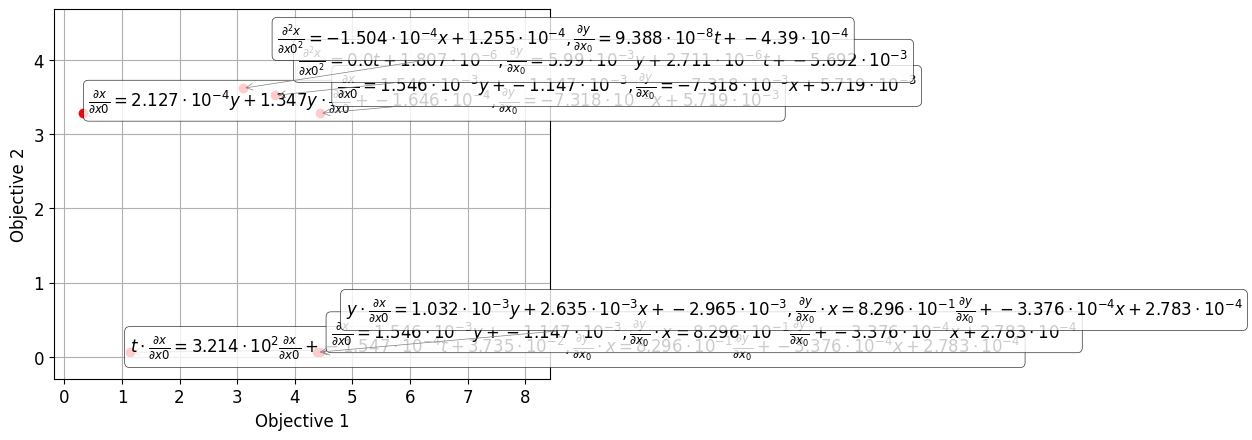

[I 2026-01-16 01:34:16,367] A new study created in memory with name: no-name-ecbf760d-3d41-4764-892e-98ce8b710f1c



System of DE 1 (startpoint 0-686):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x340605890>, <epde.structure.main_structures.SoEq object at 0x3404c3cd0>, <epde.structure.main_structures.SoEq object at 0x34238a510>, <epde.structure.main_structures.SoEq object at 0x3404c1490>, <epde.structure.main_structures.SoEq object at 0x31fde1910>, <epde.structure.main_structures.SoEq object at 0x33005bed0>, <epde.structure.main_structures.SoEq object at 0x340699b10>]
EQ 2:
Saved: output/robot_79/4_parts/without_force/system_1.csv

--- Optimizing part 2/4 (687:1374) ---
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x330848c90>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x330848c90>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2

[I 2026-01-16 01:34:44,548] Trial 0 finished with value: 2.511281443984193 and parameters: {'poly_window': 5, 'population_size': 8, 'sigma': 50, 'boundary': 6}. Best is trial 0 with value: 2.511281443984193.


The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3404823d0>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3404823d0>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [2.62482962e-08 2.56759405e-07]
New solution accepted, confirmed 1/4 solutions.
Creating new equation, sparsity value [2.42766602e-02 3.67740624e-08]
New solution accepted, confirmed 2/4 solutions.
Creating new equation, sparsity value [0.13889893 0.0034036

[I 2026-01-16 01:34:55,014] Trial 1 finished with value: 5.756454939567927 and parameters: {'poly_window': 5, 'population_size': 4, 'sigma': 55, 'boundary': 5}. Best is trial 0 with value: 2.511281443984193.


...

[I 2026-01-16 01:39:46,320] Trial 18 finished with value: 0.45043637597957065 and parameters: {'poly_window': 11, 'population_size': 7, 'sigma': 55, 'boundary': 7}. Best is trial 18 with value: 0.45043637597957065.


During MO : processing 6-th weight.
The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31f8ee410>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31f8ee410>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [0.00046492 0.07641118]
New solution accepted, confirmed 1/6 solutions.
Creating new equation, sparsity value [1.20194042e-06 1.46842938e-08]
New solution accepted, confirmed 2/6 solutions.
Creating new equation, sparsity

[I 2026-01-16 01:40:01,862] Trial 19 finished with value: 8.371021287240989 and parameters: {'poly_window': 11, 'population_size': 6, 'sigma': 55, 'boundary': 7}. Best is trial 18 with value: 0.45043637597957065.


During MO : processing 5-th weight.
The optimization has been conducted.
✅ Trial finish
✅ Part 2: Best params {'poly_window': 11, 'population_size': 7, 'sigma': 55, 'boundary': 7}, score=0.45043637597957065


setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31fd18d10>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31fd18d10>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [1.84042566e-01 1.31389891e-06]
New solution accepted, confirmed 1/7 solutions.
Creating new equation, sparsity value [8.35739217e-10 1.95898528e-04]
New solution accepted, confirmed 2/7 solutions.
Creating new equation, sparsity value [1.50963685e-08 2.19897166e-05]
New solution accepted, confirmed 3/7 solu

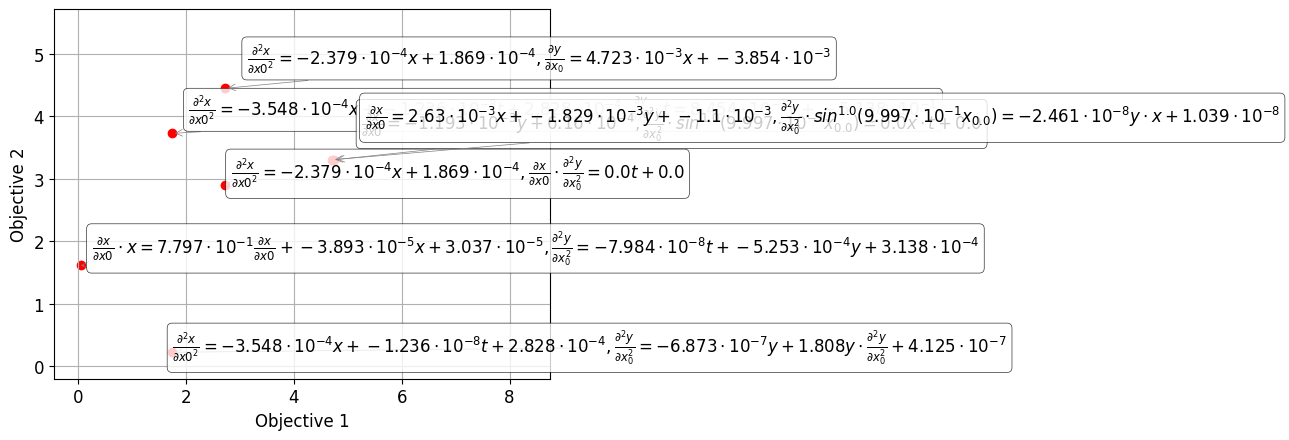

[I 2026-01-16 01:40:52,678] A new study created in memory with name: no-name-0f93c838-9663-440c-acc5-442ccb952607



System of DE 2 (startpoint 687-1373):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x31fdea3d0>, <epde.structure.main_structures.SoEq object at 0x31fd5ecd0>, <epde.structure.main_structures.SoEq object at 0x3308d6510>, <epde.structure.main_structures.SoEq object at 0x31fcabcd0>, <epde.structure.main_structures.SoEq object at 0x31faa0410>, <epde.structure.main_structures.SoEq object at 0x31f647090>, <epde.structure.main_structures.SoEq object at 0x31f440cd0>]
Saved: output/robot_79/4_parts/without_force/system_2.csv

--- Optimizing part 3/4 (1374:2061) ---
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31fe9a710>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31fe9a710>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)


[I 2026-01-16 01:41:22,402] Trial 0 finished with value: 3.9384531311944873 and parameters: {'poly_window': 5, 'population_size': 8, 'sigma': 45, 'boundary': 3}. Best is trial 0 with value: 3.9384531311944873.


The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31fc53310>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31fc53310>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [2.87004650e-07 6.67420112e-08]
New solution accepted, confirmed 1/7 solutions.
Creating new equation, sparsity value [7.19229998e-08 1.92551062e-07]
New solution accepted, confirmed 2/7 solutions.
Creating new equation, sparsity value [2.25712721e-09 3.810

[I 2026-01-16 01:41:36,868] Trial 1 finished with value: 2.5604123892118436 and parameters: {'poly_window': 5, 'population_size': 7, 'sigma': 65, 'boundary': 5}. Best is trial 1 with value: 2.5604123892118436.


...

[I 2026-01-16 01:45:38,831] Trial 18 finished with value: 5.075606839946895 and parameters: {'poly_window': 7, 'population_size': 8, 'sigma': 60, 'boundary': 5}. Best is trial 12 with value: 0.16182902947885283.


The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3302bec10>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3302bec10>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [4.33343967e-10 2.59976256e-01]
New solution accepted, confirmed 1/5 solutions.
Creating new equation, sparsity value [0.00109829 0.00980573]
New solution accepted, confirmed 2/5 solutions.
Creating new equation, sparsity value [5.96891500e-06 1.02615016e-1

[I 2026-01-16 01:45:51,532] Trial 19 finished with value: 3.7158892709586917 and parameters: {'poly_window': 9, 'population_size': 5, 'sigma': 55, 'boundary': 6}. Best is trial 12 with value: 0.16182902947885283.


During MO : processing 3-th weight.
During MO : processing 4-th weight.
The optimization has been conducted.
✅ Trial finish
✅ Part 3: Best params {'poly_window': 9, 'population_size': 6, 'sigma': 60, 'boundary': 6}, score=0.16182902947885283


setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3308e1410>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3308e1410>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [2.23861161e-04 3.36420440e-05]
New solution accepted, confirmed 1/6 solutions.
Creating new equation, sparsity value [2.04493727e-01 9.83406579e-06]
New solution accepted, confirmed 2/6 solutions.
Creating new equation, sparsity value [3.00372544e-04 5.84350529e-09]
New solution accepted, confirmed 3/6 solu

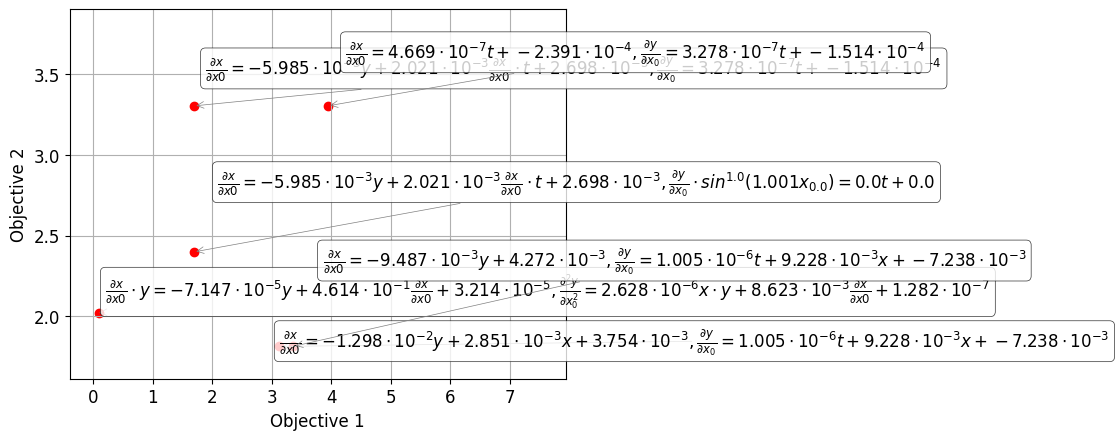

[I 2026-01-16 01:46:30,647] A new study created in memory with name: no-name-0ba8a274-9742-4ab6-83da-4d0aae7dea4b



System of DE 3 (startpoint 1374-2060):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x34065ed10>, <epde.structure.main_structures.SoEq object at 0x31fa1d510>, <epde.structure.main_structures.SoEq object at 0x31ffd2690>, <epde.structure.main_structures.SoEq object at 0x31f5c3fd0>, <epde.structure.main_structures.SoEq object at 0x3401175d0>, <epde.structure.main_structures.SoEq object at 0x31f7b9550>]
Saved: output/robot_79/4_parts/without_force/system_3.csv

--- Optimizing part 4/4 (2061:2750) ---
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31fcce150>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31fcce150>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 6
The cardinality of defined token 

[I 2026-01-16 01:46:59,240] Trial 0 finished with value: 2.583956156248805 and parameters: {'poly_window': 7, 'population_size': 8, 'sigma': 55, 'boundary': 4}. Best is trial 0 with value: 2.583956156248805.


The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x33008d290>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x33008d290>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [1.57766340e-10 2.93789669e-01]
New solution accepted, confirmed 1/8 solutions.
Creating new equation, sparsity value [2.17801062e-07 5.22282887e-04]
New solution accepted, confirmed 2/8 solutions.
Creating new equation, sparsity value [0.99365738 0.0014557

[I 2026-01-16 01:47:27,109] Trial 1 finished with value: 2.5512481793882755 and parameters: {'poly_window': 9, 'population_size': 8, 'sigma': 55, 'boundary': 5}. Best is trial 1 with value: 2.5512481793882755.


...

[I 2026-01-16 01:51:32,484] Trial 18 finished with value: 2.940389916026611 and parameters: {'poly_window': 11, 'population_size': 6, 'sigma': 50, 'boundary': 7}. Best is trial 16 with value: 0.15462449962119434.


setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31fb150d0>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31fb150d0>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [0.00169233 0.00060444]
New solution accepted, confirmed 1/6 solutions.
Creating new equation, sparsity value [5.00543668e-10 4.29879893e-09]
New solution accepted, confirmed 2/6 solutions.
Creating new equation, sparsity value [1.64039182e-09 2.78522318e-05]
New solution accepted, confirmed 3/6 solutions.
C

[I 2026-01-16 01:51:46,539] Trial 19 finished with value: 4.539365746595408 and parameters: {'poly_window': 5, 'population_size': 6, 'sigma': 55, 'boundary': 3}. Best is trial 16 with value: 0.15462449962119434.


During MO : processing 4-th weight.
During MO : processing 5-th weight.
The optimization has been conducted.
✅ Trial finish
✅ Part 4: Best params {'poly_window': 5, 'population_size': 6, 'sigma': 55, 'boundary': 4}, score=0.15462449962119434


setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31fc79410>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31fc79410>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [8.27912763e-05 3.36110936e-08]
New solution accepted, confirmed 1/6 solutions.
Creating new equation, sparsity value [8.9402714e-07 1.2030725e-06]
New solution accepted, confirmed 2/6 solutions.
Creating new equation, sparsity value [1.12286269e-05 3.77869297e-10]
New solution accepted, confirmed 3/6 soluti

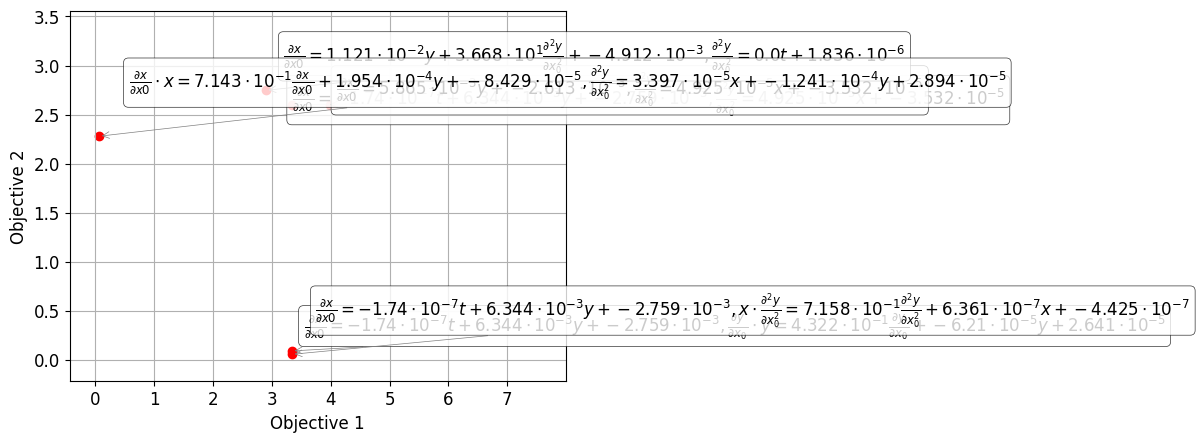


System of DE 4 (startpoint 2061-2749):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x31f52ee10>, <epde.structure.main_structures.SoEq object at 0x31f8715d0>, <epde.structure.main_structures.SoEq object at 0x3301b52d0>, <epde.structure.main_structures.SoEq object at 0x31f59bf90>, <epde.structure.main_structures.SoEq object at 0x330d90390>, <epde.structure.main_structures.SoEq object at 0x330136e50>]
Saved: output/robot_79/4_parts/without_force/system_4.csv
































[I 2026-01-16 01:52:29,192] A new study created in memory with name: no-name-a8d8f433-0b4d-45d8-9344-535edbb14f22



 Processing robot 83 with 4 parts...

--- Optimizing part 1/4 (0:687) ---
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3310b2110>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3310b2110>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [1.96290690e-03 1.00775591e-09]
New solution accepted, confirmed 1/6 solutions.
Creating new equation, sparsity value [2.09760943e-03 1.12898062e-05]
New solution accepted, confirmed 2/6 solutions.
Creating new equation, sparsity valu

[I 2026-01-16 01:52:42,763] Trial 0 finished with value: 3.439214068770794 and parameters: {'poly_window': 11, 'population_size': 6, 'sigma': 35, 'boundary': 7}. Best is trial 0 with value: 3.439214068770794.


The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x330219410>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x330219410>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [3.13873883e-02 1.50994979e-08]
New solution accepted, confirmed 1/6 solutions.
Creating new equation, sparsity value [1.28016220e-10 8.13110536e-02]
New solution accepted, confirmed 2/6 solutions.
Creating new equation, sparsity value [5.58231777e-03 8.807

...

[I 2026-01-16 01:57:00,482] Trial 18 finished with value: 2.1844889214588097 and parameters: {'poly_window': 5, 'population_size': 4, 'sigma': 60, 'boundary': 7}. Best is trial 5 with value: 0.265395785624148.


During MO : processing 2-th weight.
During MO : processing 3-th weight.
The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x330ca79d0>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x330ca79d0>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [9.79400132e-06 9.80257973e-05]
New solution accepted, confirmed 1/5 solutions.
Creating new equation, sparsity value [2.04200533e-07 1.01998724e-10]
New solution accepted, confirmed 2/

[I 2026-01-16 01:57:14,097] Trial 19 finished with value: 4.6600046051842785 and parameters: {'poly_window': 7, 'population_size': 5, 'sigma': 50, 'boundary': 7}. Best is trial 5 with value: 0.265395785624148.


During MO : processing 4-th weight.
The optimization has been conducted.
✅ Trial finish
✅ Part 1: Best params {'poly_window': 5, 'population_size': 4, 'sigma': 45, 'boundary': 7}, score=0.265395785624148


setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x340201410>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x340201410>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [3.94241045e-02 5.83477428e-07]
New solution accepted, confirmed 1/4 solutions.
Creating new equation, sparsity value [5.08916831e-09 5.65351430e-01]
New solution accepted, confirmed 2/4 solutions.
Creating new equation, sparsity value [1.91125883e-01 5.36406665e-09]
New solution accepted, confirmed 3/4 solu

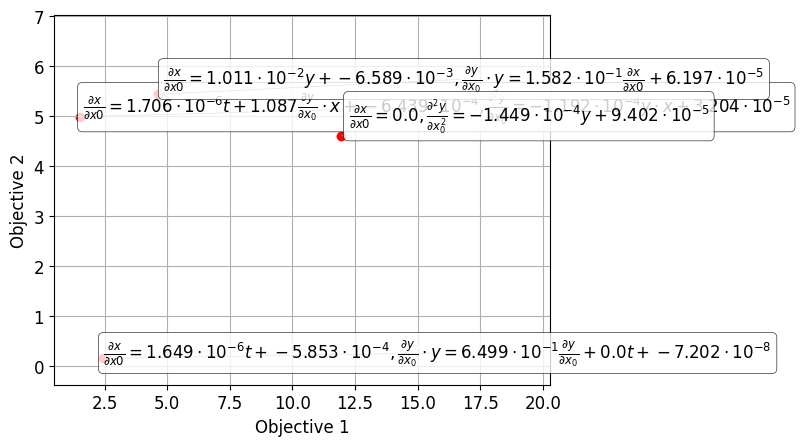

[I 2026-01-16 01:57:41,812] A new study created in memory with name: no-name-31e4b413-5b27-4986-bfd4-afce85c6c3db



System of DE 1 (startpoint 0-686):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x31f951b10>, <epde.structure.main_structures.SoEq object at 0x31fc607d0>, <epde.structure.main_structures.SoEq object at 0x31f7cde90>, <epde.structure.main_structures.SoEq object at 0x33c606210>]
Saved: output/robot_83/4_parts/without_force/system_1.csv

--- Optimizing part 2/4 (687:1374) ---
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x330000c90>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x330000c90>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!

[I 2026-01-16 01:57:56,550] Trial 0 finished with value: 2.959965419205331 and parameters: {'poly_window': 11, 'population_size': 7, 'sigma': 40, 'boundary': 7}. Best is trial 0 with value: 2.959965419205331.


The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x337e19110>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x337e19110>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [2.03520586e-09 1.79340886e-03]
New solution accepted, confirmed 1/5 solutions.
Creating new equation, sparsity value [0.0010736  0.00114121]
New solution accepted, confirmed 2/5 solutions.
Creating new equation, sparsity value [0.01853743 0.0011345 ]
New s

[I 2026-01-16 01:58:10,485] Trial 1 finished with value: 2.134629174513951 and parameters: {'poly_window': 7, 'population_size': 5, 'sigma': 45, 'boundary': 6}. Best is trial 1 with value: 2.134629174513951.


...

[I 2026-01-16 02:03:33,176] Trial 18 finished with value: 4.108752464811947 and parameters: {'poly_window': 7, 'population_size': 6, 'sigma': 55, 'boundary': 6}. Best is trial 13 with value: 0.1858114007883928.


The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x330de7d10>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x330de7d10>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [4.38196176e-02 4.89693003e-05]
New solution accepted, confirmed 1/8 solutions.
Creating new equation, sparsity value [2.13894174e-08 4.15122176e-03]
New solution accepted, confirmed 2/8 solutions.
Creating new equation, sparsity value [1.93052473e-03 4.949

[I 2026-01-16 02:04:01,237] Trial 19 finished with value: 0.11885323022050254 and parameters: {'poly_window': 9, 'population_size': 8, 'sigma': 50, 'boundary': 6}. Best is trial 19 with value: 0.11885323022050254.


The optimization has been conducted.
✅ Trial finish
✅ Part 2: Best params {'poly_window': 9, 'population_size': 8, 'sigma': 50, 'boundary': 6}, score=0.11885323022050254


setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x330ca1410>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x330ca1410>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [5.02890192e-03 7.51903704e-08]
New solution accepted, confirmed 1/8 solutions.
Creating new equation, sparsity value [1.36169551e-06 3.15187256e-09]
New solution accepted, confirmed 2/8 solutions.
Creating new equation, sparsity value [1.78186719e-06 4.29459466e-06]
New solution accepted, confirmed 3/8 solu

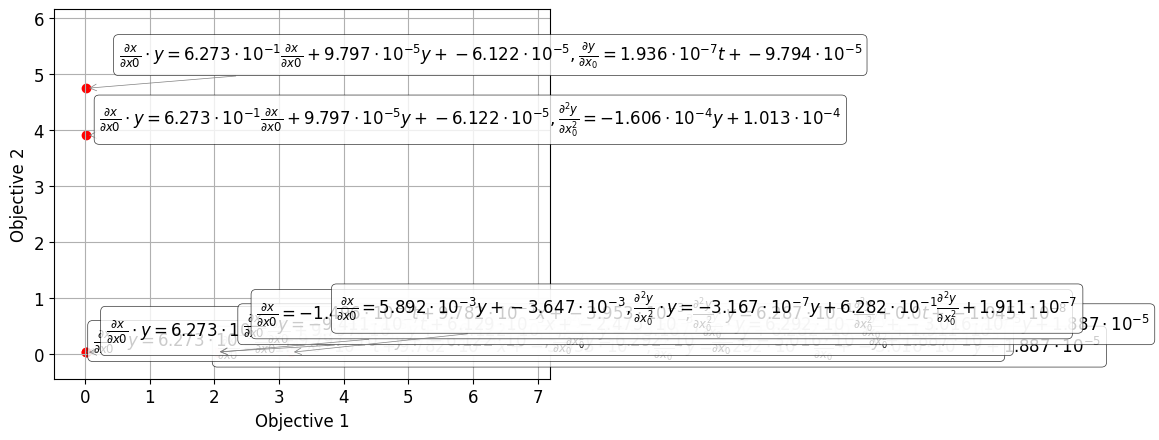

[I 2026-01-16 02:05:47,799] A new study created in memory with name: no-name-6e2c5fef-4387-4b0f-9141-e05ef8008f27



System of DE 2 (startpoint 687-1373):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x331469b50>, <epde.structure.main_structures.SoEq object at 0x33115f590>, <epde.structure.main_structures.SoEq object at 0x3311e8dd0>, <epde.structure.main_structures.SoEq object at 0x33c25d290>, <epde.structure.main_structures.SoEq object at 0x3312a40d0>, <epde.structure.main_structures.SoEq object at 0x33c2ce9d0>, <epde.structure.main_structures.SoEq object at 0x331aafd50>, <epde.structure.main_structures.SoEq object at 0x33197c210>]
Saved: output/robot_83/4_parts/without_force/system_2.csv

--- Optimizing part 3/4 (1374:2061) ---
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31f8540d0>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31f8540d0>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [

[I 2026-01-16 02:05:59,038] Trial 0 finished with value: 3.935828540122129 and parameters: {'poly_window': 11, 'population_size': 4, 'sigma': 50, 'boundary': 7}. Best is trial 0 with value: 3.935828540122129.


During MO : processing 3-th weight.
The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31fa74810>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31fa74810>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [9.50441347e-10 3.31981485e-08]
New solution accepted, confirmed 1/8 solutions.
Creating new equation, sparsity value [0.05940981 0.00188078]
New solution accepted, confirmed 2/8 solutions.
Creating new equation, sparsity

[I 2026-01-16 02:06:26,475] Trial 1 finished with value: 4.467920630178865 and parameters: {'poly_window': 7, 'population_size': 8, 'sigma': 50, 'boundary': 6}. Best is trial 0 with value: 3.935828540122129.


...

[I 2026-01-16 02:10:49,252] Trial 18 finished with value: 4.273518395216914 and parameters: {'poly_window': 9, 'population_size': 7, 'sigma': 60, 'boundary': 7}. Best is trial 17 with value: 0.8304786195371882.


setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x308511d10>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x308511d10>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [3.31893215e-05 1.87894176e-10]
New solution accepted, confirmed 1/7 solutions.
Creating new equation, sparsity value [4.99906392e-05 3.53226422e-09]
New solution accepted, confirmed 2/7 solutions.
Creating new equation, sparsity value [0.00799738 0.09917075]
New solution accepted, confirmed 3/7 solutions.
C

[I 2026-01-16 02:11:04,724] Trial 19 finished with value: 3.340491700832133 and parameters: {'poly_window': 11, 'population_size': 7, 'sigma': 55, 'boundary': 7}. Best is trial 17 with value: 0.8304786195371882.


During MO : processing 6-th weight.
The optimization has been conducted.
✅ Trial finish
✅ Part 3: Best params {'poly_window': 11, 'population_size': 7, 'sigma': 55, 'boundary': 7}, score=0.8304786195371882


setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x340171fd0>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x340171fd0>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [0.00072636 0.02957333]
New solution accepted, confirmed 1/7 solutions.
Creating new equation, sparsity value [0.00012217 0.00045317]
New solution accepted, confirmed 2/7 solutions.
Creating new equation, sparsity value [2.26700279e-06 1.05534491e-04]
New solution accepted, confirmed 3/7 solutions.
Creating 

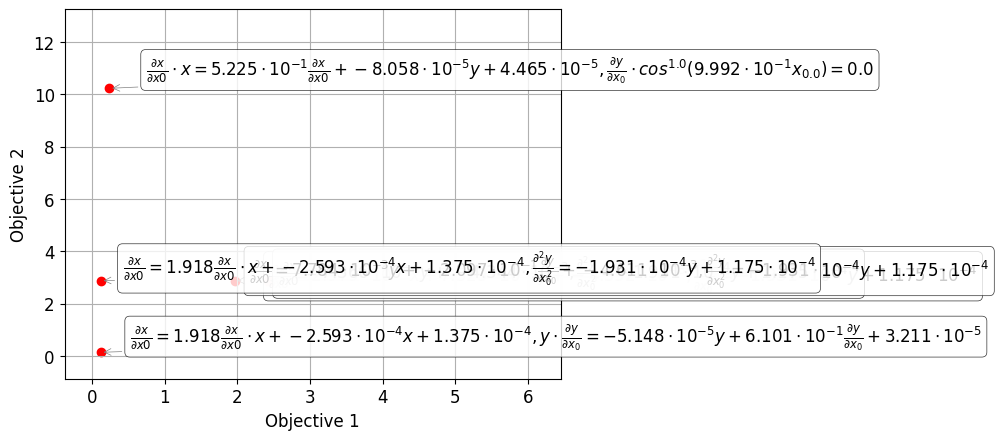

[I 2026-01-16 02:11:49,541] A new study created in memory with name: no-name-29909e3a-9d1b-4191-a068-ce3bbf4079b2



System of DE 3 (startpoint 1374-2060):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x330d7fe50>, <epde.structure.main_structures.SoEq object at 0x3315b5550>, <epde.structure.main_structures.SoEq object at 0x331bf2510>, <epde.structure.main_structures.SoEq object at 0x33478cd10>, <epde.structure.main_structures.SoEq object at 0x334739d90>, <epde.structure.main_structures.SoEq object at 0x3345e37d0>]
EQ 2:
Saved: output/robot_83/4_parts/without_force/system_3.csv

--- Optimizing part 4/4 (2061:2750) ---
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x334534e90>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x334534e90>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 6
The cardinality of defined 

[I 2026-01-16 02:12:04,968] Trial 0 finished with value: 2.1181967384832534 and parameters: {'poly_window': 7, 'population_size': 7, 'sigma': 55, 'boundary': 5}. Best is trial 0 with value: 2.1181967384832534.


Restoring containment of y in k_0 y{power: 1.0} + k_1 t{power: 1.0, dim: 0.0} + k_2 x{power: 1.0} + k_3 = 0.
During MO : processing 6-th weight.
The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x331ae4550>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x331ae4550>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [1.18439179e-06 1.11498836e-03]
New solution accepted, confirmed 1/6 solutions.
Creating new equation, sparsity 

[I 2026-01-16 02:12:19,609] Trial 1 finished with value: 2.719670172111626 and parameters: {'poly_window': 9, 'population_size': 6, 'sigma': 45, 'boundary': 5}. Best is trial 0 with value: 2.1181967384832534.


...

[I 2026-01-16 02:16:43,769] Trial 18 finished with value: 6.784086086438001 and parameters: {'poly_window': 7, 'population_size': 4, 'sigma': 65, 'boundary': 4}. Best is trial 2 with value: 0.18812136250637806.


The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x330b2ab90>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x330b2ab90>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [2.95165742e-04 7.73246617e-07]
New solution accepted, confirmed 1/6 solutions.
Creating new equation, sparsity value [3.59139579e-07 2.79519096e-03]
New solution accepted, confirmed 2/6 solutions.
Creating new equation, sparsity value [2.36319444e-09 3.751

[I 2026-01-16 02:16:55,778] Trial 19 finished with value: 3.650985271195316 and parameters: {'poly_window': 5, 'population_size': 6, 'sigma': 60, 'boundary': 3}. Best is trial 2 with value: 0.18812136250637806.


During MO : processing 4-th weight.
During MO : processing 5-th weight.
The optimization has been conducted.
✅ Trial finish
✅ Part 4: Best params {'poly_window': 11, 'population_size': 5, 'sigma': 40, 'boundary': 6}, score=0.18812136250637806


setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x331891410>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x331891410>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [2.90098618e-02 3.40135204e-07]
New solution accepted, confirmed 1/5 solutions.
Creating new equation, sparsity value [1.83809563e-08 8.65682629e-05]
New solution accepted, confirmed 2/5 solutions.
Creating new equation, sparsity value [0.00045    0.03454793]
New solution accepted, confirmed 3/5 solutions.
C

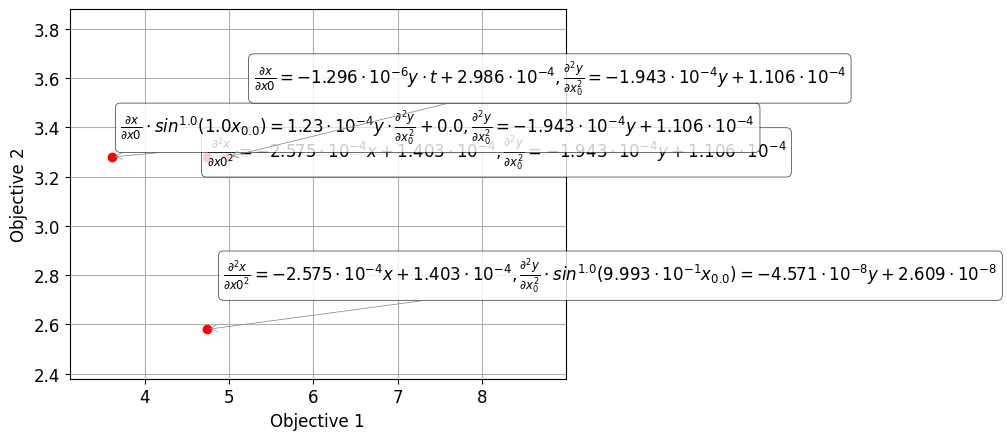


System of DE 4 (startpoint 2061-2749):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x330b6ce90>, <epde.structure.main_structures.SoEq object at 0x33115e890>, <epde.structure.main_structures.SoEq object at 0x334a88d90>, <epde.structure.main_structures.SoEq object at 0x334b446d0>]
EQ 2:
Saved: output/robot_83/4_parts/without_force/system_4.csv
































[I 2026-01-16 02:17:29,225] A new study created in memory with name: no-name-8163bceb-0152-44f7-a850-06551693fc85



 Processing robot 31 with 4 parts...

--- Optimizing part 1/4 (0:687) ---
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x331223710>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x331223710>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [5.97408237e-06 9.29165885e-09]
New solution accepted, confirmed 1/7 solutions.
Creating new equation, sparsity value [5.37877641e-05 2.74085491e-01]
New solution accepted, confirmed 2/7 solutions.
Creating new equation, sparsity valu

[I 2026-01-16 02:17:44,338] Trial 0 finished with value: 5.124940813847367 and parameters: {'poly_window': 9, 'population_size': 7, 'sigma': 45, 'boundary': 5}. Best is trial 0 with value: 5.124940813847367.


During MO : processing 5-th weight.
During MO : processing 6-th weight.
The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3312f3750>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3312f3750>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [2.96403210e-03 8.21160172e-08]
New solution accepted, confirmed 1/4 solutions.
Creating new equation, sparsity value [1.29624615e-07 4.44695531e-02]
New solution accepted, confirmed 2/

...

[I 2026-01-16 02:23:01,916] Trial 18 finished with value: 3.0018891523456848 and parameters: {'poly_window': 9, 'population_size': 8, 'sigma': 65, 'boundary': 6}. Best is trial 16 with value: 0.19506373687731873.


The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3305b0a90>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3305b0a90>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [6.71019196e-05 6.96759198e-02]
New solution accepted, confirmed 1/8 solutions.
Creating new equation, sparsity value [0.00129206 0.00101785]
New solution accepted, confirmed 2/8 solutions.
Creating new equation, sparsity value [0.35881696 0.00217012]
New s

[I 2026-01-16 02:23:27,868] Trial 19 finished with value: 4.917792022610016 and parameters: {'poly_window': 11, 'population_size': 8, 'sigma': 55, 'boundary': 6}. Best is trial 16 with value: 0.19506373687731873.


The optimization has been conducted.
✅ Trial finish
✅ Part 1: Best params {'poly_window': 5, 'population_size': 8, 'sigma': 65, 'boundary': 6}, score=0.19506373687731873


setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x33bb49410>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x33bb49410>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [7.24164269e-06 8.43354514e-06]
New solution accepted, confirmed 1/8 solutions.
Creating new equation, sparsity value [1.30146507e-01 1.55423802e-09]
New solution accepted, confirmed 2/8 solutions.
Creating new equation, sparsity value [2.84223667e-06 3.13202351e-06]
New solution accepted, confirmed 3/8 solu

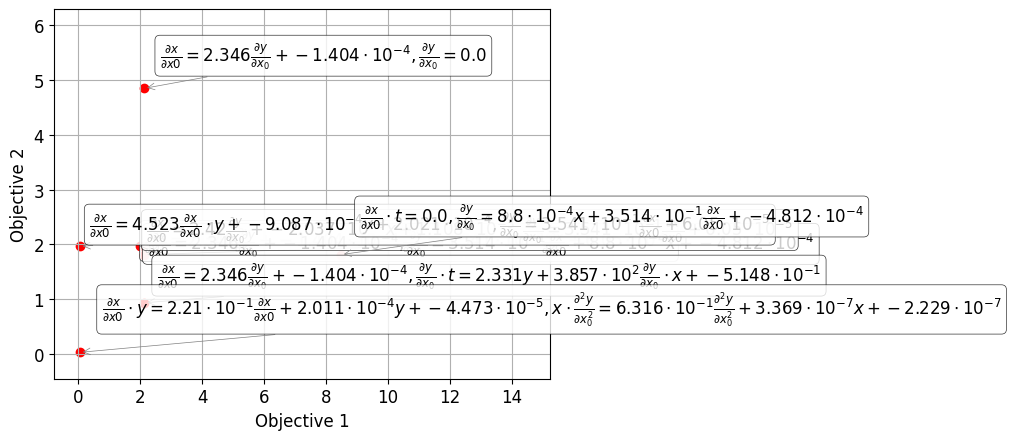

[I 2026-01-16 02:25:34,971] A new study created in memory with name: no-name-c162ddb9-cd6c-4209-aa63-878817950592



System of DE 1 (startpoint 0-686):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x3312b26d0>, <epde.structure.main_structures.SoEq object at 0x330912450>, <epde.structure.main_structures.SoEq object at 0x331385dd0>, <epde.structure.main_structures.SoEq object at 0x331107790>, <epde.structure.main_structures.SoEq object at 0x330f34f90>, <epde.structure.main_structures.SoEq object at 0x330e2b590>, <epde.structure.main_structures.SoEq object at 0x341e3ad50>, <epde.structure.main_structures.SoEq object at 0x331098590>]
Saved: output/robot_31/4_parts/without_force/system_1.csv

--- Optimizing part 2/4 (687:1374) ---
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31f7a4e90>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31f7a4e90>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0

[I 2026-01-16 02:25:48,009] Trial 0 finished with value: 7.235243540954803 and parameters: {'poly_window': 7, 'population_size': 6, 'sigma': 40, 'boundary': 6}. Best is trial 0 with value: 7.235243540954803.


The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x330aed0d0>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x330aed0d0>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [5.09357228e-05 4.43708920e-05]
New solution accepted, confirmed 1/7 solutions.
Creating new equation, sparsity value [2.71271254e-07 6.49808187e-01]
New solution accepted, confirmed 2/7 solutions.
Creating new equation, sparsity value [2.05144634e-07 2.944

[I 2026-01-16 02:26:02,505] Trial 1 finished with value: 5.827439677727342 and parameters: {'poly_window': 5, 'population_size': 7, 'sigma': 55, 'boundary': 4}. Best is trial 1 with value: 5.827439677727342.


...

[I 2026-01-16 02:29:54,896] Trial 18 finished with value: 5.860298272830097 and parameters: {'poly_window': 5, 'population_size': 6, 'sigma': 55, 'boundary': 3}. Best is trial 5 with value: 0.4519955893913972.


During MO : processing 5-th weight.
The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3308f6f10>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3308f6f10>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [1.86990348e-08 1.61332389e-07]
New solution accepted, confirmed 1/8 solutions.
Creating new equation, sparsity value [0.81592395 0.03263865]
New solution accepted, confirmed 2/8 solutions.
Creating new equation, sparsity

[I 2026-01-16 02:30:20,624] Trial 19 finished with value: 3.2922963233391327 and parameters: {'poly_window': 5, 'population_size': 8, 'sigma': 60, 'boundary': 4}. Best is trial 5 with value: 0.4519955893913972.


✅ Part 2: Best params {'poly_window': 5, 'population_size': 5, 'sigma': 65, 'boundary': 5}, score=0.4519955893913972


setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3308e1410>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3308e1410>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [7.1014508e-03 9.5191142e-08]
New solution accepted, confirmed 1/5 solutions.
Creating new equation, sparsity value [8.68191628e-10 8.72291201e-10]
New solution accepted, confirmed 2/5 solutions.
Creating new equation, sparsity value [1.19175927e-04 1.08266868e-08]
New solution accepted, confirmed 3/5 soluti

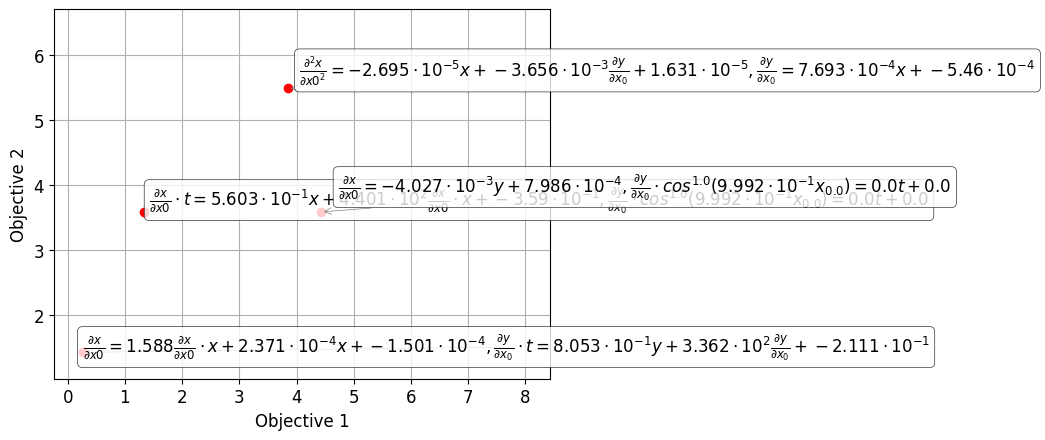

[I 2026-01-16 02:30:56,469] A new study created in memory with name: no-name-3fd86df9-58f6-4d3e-94b2-b9f1ac485fdb



System of DE 2 (startpoint 687-1373):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x31fb1e150>, <epde.structure.main_structures.SoEq object at 0x330911dd0>, <epde.structure.main_structures.SoEq object at 0x33158dd10>, <epde.structure.main_structures.SoEq object at 0x33153df90>]
EQ 2:
Saved: output/robot_31/4_parts/without_force/system_2.csv

--- Optimizing part 3/4 (1374:2061) ---
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x340159410>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x340159410>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data

[I 2026-01-16 02:31:10,661] Trial 0 finished with value: 4.295671991803278 and parameters: {'poly_window': 7, 'population_size': 6, 'sigma': 65, 'boundary': 5}. Best is trial 0 with value: 4.295671991803278.


During MO : processing 5-th weight.
The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x33076ac90>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x33076ac90>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [9.18065134e-05 2.37193658e-08]
New solution accepted, confirmed 1/7 solutions.
Creating new equation, sparsity value [0.00145498 0.07277416]
New solution accepted, confirmed 2/7 solutions.
Creating new equation, sparsity

[I 2026-01-16 02:31:25,954] Trial 1 finished with value: 7.016958122196424 and parameters: {'poly_window': 7, 'population_size': 7, 'sigma': 45, 'boundary': 4}. Best is trial 0 with value: 4.295671991803278.


...

[I 2026-01-16 02:36:46,669] Trial 18 finished with value: 7.56444324714235 and parameters: {'poly_window': 11, 'population_size': 6, 'sigma': 50, 'boundary': 6}. Best is trial 7 with value: 0.11372488755744534.


During MO : processing 5-th weight.
The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3310d1d50>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3310d1d50>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [0.00290738 0.00112569]
New solution accepted, confirmed 1/6 solutions.
Creating new equation, sparsity value [6.70705153e-05 1.53338920e-08]
New solution accepted, confirmed 2/6 solutions.
Creating new equation, sparsity

[I 2026-01-16 02:37:00,384] Trial 19 finished with value: 5.279000718960887 and parameters: {'poly_window': 9, 'population_size': 6, 'sigma': 55, 'boundary': 5}. Best is trial 7 with value: 0.11372488755744534.


The optimization has been conducted.
✅ Trial finish
✅ Part 3: Best params {'poly_window': 11, 'population_size': 7, 'sigma': 55, 'boundary': 6}, score=0.11372488755744534


setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x341e39410>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x341e39410>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [3.28579526e-10 2.03522567e-10]
New solution accepted, confirmed 1/7 solutions.
Creating new equation, sparsity value [7.55012235e-08 3.88002995e-02]
New solution accepted, confirmed 2/7 solutions.
Creating new equation, sparsity value [1.38883373e-05 5.57935483e-09]
New solution accepted, confirmed 3/7 solu

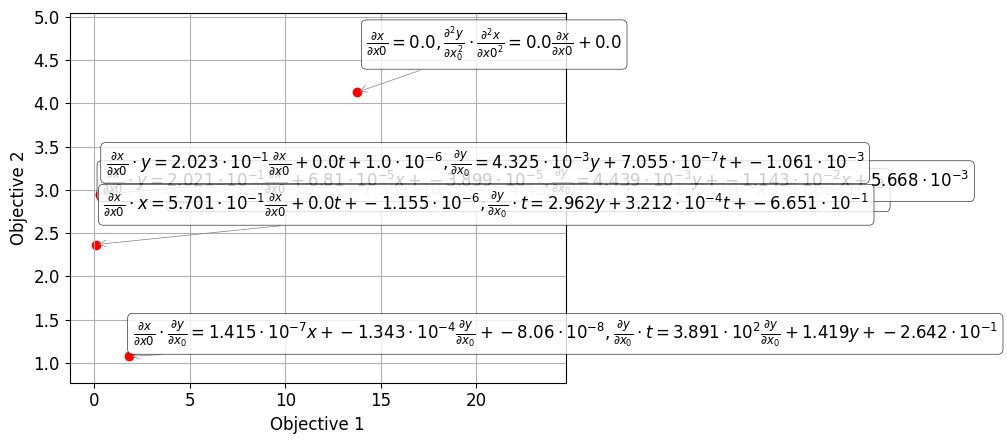

[I 2026-01-16 02:37:54,158] A new study created in memory with name: no-name-983a6201-193f-45b0-b009-4b90d37a919f



System of DE 3 (startpoint 1374-2060):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x331733b10>, <epde.structure.main_structures.SoEq object at 0x330fbb010>, <epde.structure.main_structures.SoEq object at 0x3313ba890>, <epde.structure.main_structures.SoEq object at 0x3313672d0>, <epde.structure.main_structures.SoEq object at 0x330e8d310>, <epde.structure.main_structures.SoEq object at 0x331427a10>]
EQ 2:
Saved: output/robot_31/4_parts/without_force/system_3.csv

--- Optimizing part 4/4 (2061:2750) ---
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31fdc6990>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31fdc6990>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 6
The cardinality of defined 

[I 2026-01-16 02:38:08,845] Trial 0 finished with value: 6.988158000207357 and parameters: {'poly_window': 7, 'population_size': 5, 'sigma': 35, 'boundary': 5}. Best is trial 0 with value: 6.988158000207357.


setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31f951ed0>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31f951ed0>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [4.94007039e-06 1.16911295e-09]
New solution accepted, confirmed 1/5 solutions.
Creating new equation, sparsity value [1.14950091e-07 1.31660999e-10]
New solution accepted, confirmed 2/5 solutions.
Creating new equation, sparsity value [0.00299174 0.00080699]
New solution accepted, confirmed 3/5 solutions.
C

[I 2026-01-16 02:38:23,218] Trial 1 finished with value: 2.4980442410708643 and parameters: {'poly_window': 9, 'population_size': 5, 'sigma': 55, 'boundary': 6}. Best is trial 1 with value: 2.4980442410708643.


...

[I 2026-01-16 02:42:03,076] Trial 18 finished with value: 2.063369572914299 and parameters: {'poly_window': 9, 'population_size': 4, 'sigma': 45, 'boundary': 6}. Best is trial 18 with value: 2.063369572914299.


During MO : processing 2-th weight.
During MO : processing 3-th weight.
The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31fe74210>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31fe74210>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [6.42637582e-03 1.48837176e-09]
New solution accepted, confirmed 1/4 solutions.
Creating new equation, sparsity value [1.60493795e-06 5.50618072e-06]
New solution accepted, confirmed 2/

[I 2026-01-16 02:42:13,284] Trial 19 finished with value: 5.687372239910895 and parameters: {'poly_window': 11, 'population_size': 4, 'sigma': 40, 'boundary': 7}. Best is trial 18 with value: 2.063369572914299.


During MO : processing 3-th weight.
The optimization has been conducted.
✅ Trial finish
✅ Part 4: Best params {'poly_window': 9, 'population_size': 4, 'sigma': 45, 'boundary': 6}, score=2.063369572914299


setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x330eb1e90>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x330eb1e90>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [1.99673894e-05 1.37093367e-10]
New solution accepted, confirmed 1/4 solutions.
Creating new equation, sparsity value [4.31678867e-09 3.06953208e-06]
New solution accepted, confirmed 2/4 solutions.
Creating new equation, sparsity value [3.61885458e-06 1.67977483e-02]
New solution accepted, confirmed 3/4 solu

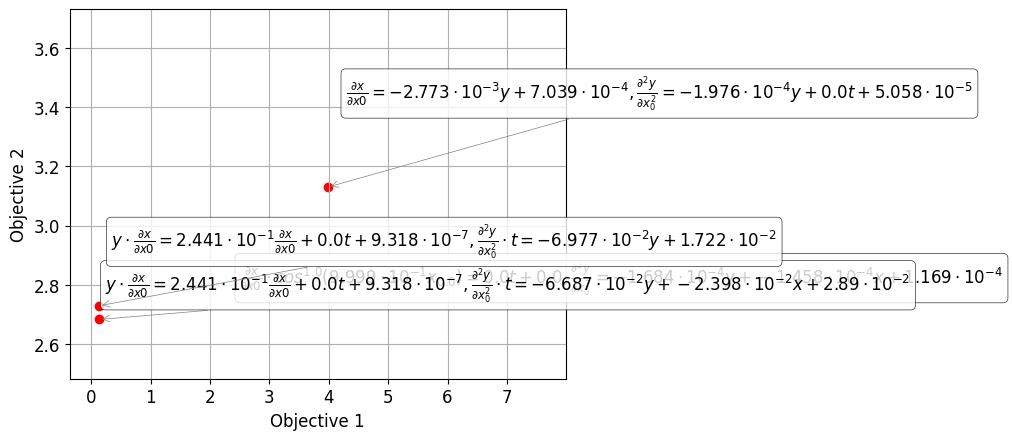


System of DE 4 (startpoint 2061-2749):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x3316df5d0>, <epde.structure.main_structures.SoEq object at 0x331858290>, <epde.structure.main_structures.SoEq object at 0x331613ad0>, <epde.structure.main_structures.SoEq object at 0x331735550>]
Saved: output/robot_31/4_parts/without_force/system_4.csv
































[I 2026-01-16 02:42:44,765] A new study created in memory with name: no-name-309a128f-2a9e-4aa1-aeb6-4389c9807230



 Processing robot 32 with 4 parts...

--- Optimizing part 1/4 (0:687) ---
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3400943d0>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3400943d0>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [1.51616396e-08 1.37369041e-06]
New solution accepted, confirmed 1/8 solutions.
Creating new equation, sparsity value [2.19757952e-07 1.70346741e-06]
New solution accepted, confirmed 2/8 solutions.
Creating new equation, sparsity valu

[I 2026-01-16 02:43:10,491] Trial 0 finished with value: 3.3784614522186747 and parameters: {'poly_window': 5, 'population_size': 8, 'sigma': 65, 'boundary': 6}. Best is trial 0 with value: 3.3784614522186747.


The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3401e0210>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3401e0210>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [3.92911300e-06 5.24338022e-04]
New solution accepted, confirmed 1/5 solutions.
Creating new equation, sparsity value [2.56613602e-02 1.12044218e-07]
New solution accepted, confirmed 2/5 solutions.
Creating new equation, sparsity value [0.00019811 0.0010618

...

[I 2026-01-16 02:47:40,169] Trial 18 finished with value: 5.416949832034387 and parameters: {'poly_window': 5, 'population_size': 5, 'sigma': 55, 'boundary': 4}. Best is trial 4 with value: 0.6146039989758392.


During MO : processing 4-th weight.
The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x330b230d0>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x330b230d0>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [4.28219664e-08 7.80655329e-09]
New solution accepted, confirmed 1/7 solutions.
Creating new equation, sparsity value [3.03973332e-06 6.46951470e-04]
New solution accepted, confirmed 2/7 solutions.
Creating new equation, 

[I 2026-01-16 02:47:55,280] Trial 19 finished with value: 2.434492958763492 and parameters: {'poly_window': 7, 'population_size': 7, 'sigma': 65, 'boundary': 5}. Best is trial 4 with value: 0.6146039989758392.


During MO : processing 6-th weight.
The optimization has been conducted.
✅ Trial finish
✅ Part 1: Best params {'poly_window': 5, 'population_size': 8, 'sigma': 40, 'boundary': 6}, score=0.6146039989758392


setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x308981410>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x308981410>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [8.90646113e-02 9.42211651e-08]
New solution accepted, confirmed 1/8 solutions.
Creating new equation, sparsity value [1.71399858e-06 2.45034307e-05]
New solution accepted, confirmed 2/8 solutions.
Creating new equation, sparsity value [0.00037791 0.00618134]
New solution accepted, confirmed 3/8 solutions.
C

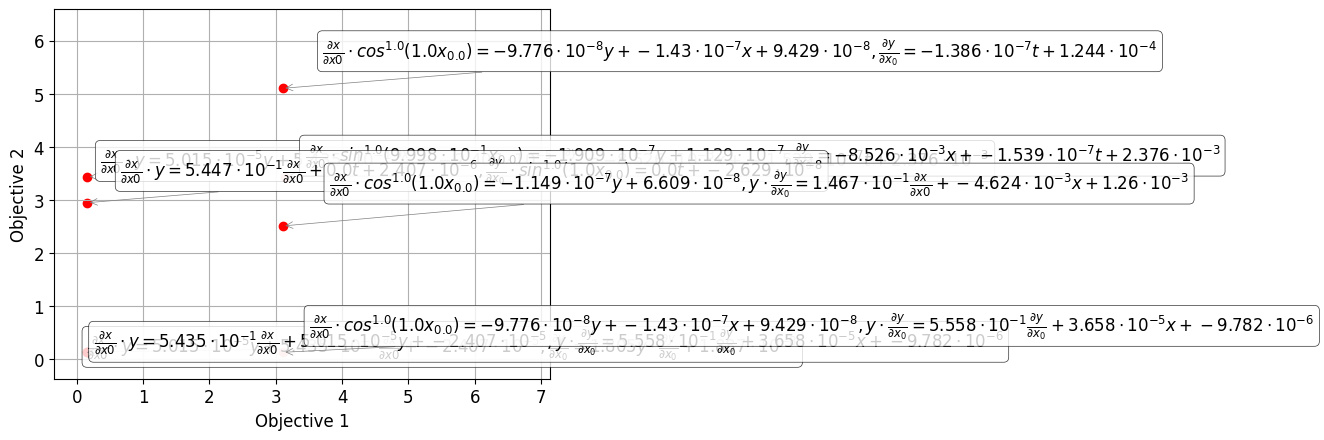

[I 2026-01-16 02:49:49,366] A new study created in memory with name: no-name-98b97e0b-9626-40ff-bc5a-22f41ff80197



System of DE 1 (startpoint 0-686):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x331691610>, <epde.structure.main_structures.SoEq object at 0x337df1c50>, <epde.structure.main_structures.SoEq object at 0x334936e90>, <epde.structure.main_structures.SoEq object at 0x33109b550>, <epde.structure.main_structures.SoEq object at 0x3089d86d0>, <epde.structure.main_structures.SoEq object at 0x334c05110>, <epde.structure.main_structures.SoEq object at 0x3345ac690>, <epde.structure.main_structures.SoEq object at 0x331af2190>]
Saved: output/robot_32/4_parts/without_force/system_1.csv

--- Optimizing part 2/4 (687:1374) ---
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3316c8c90>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3316c8c90>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0

[I 2026-01-16 02:50:02,859] Trial 0 finished with value: 4.600494863899634 and parameters: {'poly_window': 5, 'population_size': 6, 'sigma': 50, 'boundary': 3}. Best is trial 0 with value: 4.600494863899634.


setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31ff59410>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31ff59410>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [1.73140423e-08 2.27978769e-06]
New solution accepted, confirmed 1/8 solutions.
Creating new equation, sparsity value [3.47393289e-08 1.62397005e-08]
New solution accepted, confirmed 2/8 solutions.
Creating new equation, sparsity value [1.22353890e-05 1.51453295e-08]
New solution accepted, confirmed 3/8 solu

[I 2026-01-16 02:50:31,315] Trial 1 finished with value: 0.7814515942463642 and parameters: {'poly_window': 5, 'population_size': 8, 'sigma': 50, 'boundary': 3}. Best is trial 1 with value: 0.7814515942463642.


...

[I 2026-01-16 02:55:40,716] Trial 18 finished with value: 4.715395005485272 and parameters: {'poly_window': 5, 'population_size': 5, 'sigma': 50, 'boundary': 3}. Best is trial 16 with value: 0.6511428165748238.


During MO : processing 4-th weight.
The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x33483e810>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x33483e810>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [1.91702725e-06 2.41634374e-02]
New solution accepted, confirmed 1/6 solutions.
Creating new equation, sparsity value [3.11428221e-07 8.31545884e-07]
New solution accepted, confirmed 2/6 solutions.
Creating new equation, 

[I 2026-01-16 02:55:54,222] Trial 19 finished with value: 2.5358592880262742 and parameters: {'poly_window': 5, 'population_size': 6, 'sigma': 45, 'boundary': 4}. Best is trial 16 with value: 0.6511428165748238.


Restoring containment of x in k_0 x{power: 1.0} + k_1 d^2y/dx0^2{power: 1.0} + k_2 y{power: 1.0} + k_3 = 0.
The optimization has been conducted.
✅ Trial finish
✅ Part 2: Best params {'poly_window': 5, 'population_size': 8, 'sigma': 55, 'boundary': 3}, score=0.6511428165748238


setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x337e19410>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x337e19410>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [1.49174366e-05 4.79053422e-09]
New solution accepted, confirmed 1/8 solutions.
Creating new equation, sparsity value [1.02663650e-09 4.76475959e-06]
New solution accepted, confirmed 2/8 solutions.
Creating new equation, sparsity value [3.30773679e-04 3.08957411e-06]
New solution accepted, confirmed 3/8 solu

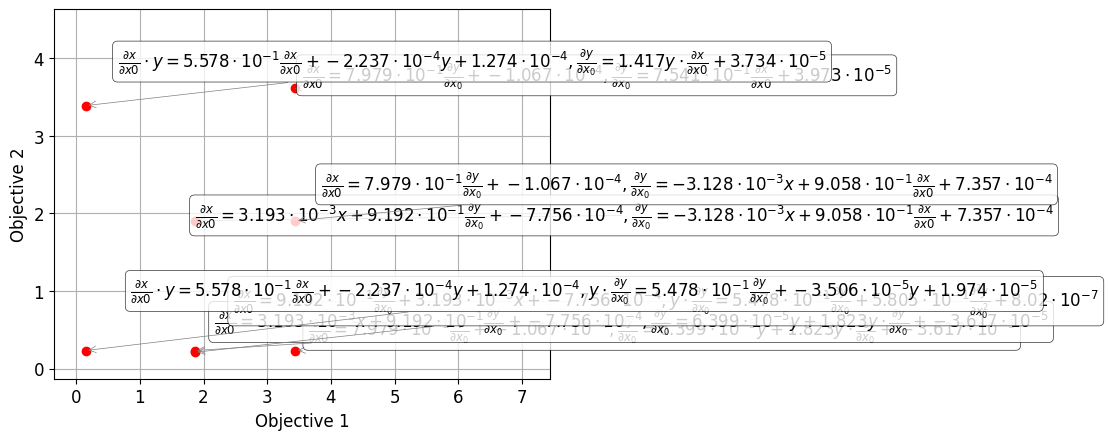

[I 2026-01-16 02:57:23,278] A new study created in memory with name: no-name-c79e8065-c79f-4a0f-85cb-3026a02c3bb4



System of DE 2 (startpoint 687-1373):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x334921390>, <epde.structure.main_structures.SoEq object at 0x331be9910>, <epde.structure.main_structures.SoEq object at 0x331221d10>, <epde.structure.main_structures.SoEq object at 0x33c609d10>, <epde.structure.main_structures.SoEq object at 0x33473ead0>, <epde.structure.main_structures.SoEq object at 0x33509c290>, <epde.structure.main_structures.SoEq object at 0x331c21dd0>, <epde.structure.main_structures.SoEq object at 0x334d5c410>]
Saved: output/robot_32/4_parts/without_force/system_2.csv

--- Optimizing part 3/4 (1374:2061) ---
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3319d3190>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3319d3190>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [

[I 2026-01-16 02:57:35,861] Trial 0 finished with value: 2.3747279059631365 and parameters: {'poly_window': 5, 'population_size': 6, 'sigma': 60, 'boundary': 6}. Best is trial 0 with value: 2.3747279059631365.


During MO : processing 5-th weight.
The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3318d5e50>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3318d5e50>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [0.00044527 0.00200851]
New solution accepted, confirmed 1/5 solutions.
Creating new equation, sparsity value [0.05581268 0.13949734]
New solution accepted, confirmed 2/5 solutions.
Creating new equation, sparsity value [

[I 2026-01-16 02:57:48,721] Trial 1 finished with value: 3.6071515807991084 and parameters: {'poly_window': 11, 'population_size': 5, 'sigma': 50, 'boundary': 7}. Best is trial 0 with value: 2.3747279059631365.


...

[I 2026-01-16 03:03:18,464] Trial 18 finished with value: 0.8980833489468013 and parameters: {'poly_window': 9, 'population_size': 8, 'sigma': 65, 'boundary': 6}. Best is trial 18 with value: 0.8980833489468013.


During MO : processing 7-th weight.
The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3307cd4d0>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3307cd4d0>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [0.00087617 0.00011379]
New solution accepted, confirmed 1/5 solutions.
Creating new equation, sparsity value [0.00035277 0.00259056]
New solution accepted, confirmed 2/5 solutions.
Creating new equation, sparsity value [

[I 2026-01-16 03:03:29,397] Trial 19 finished with value: 1.705261481628476 and parameters: {'poly_window': 7, 'population_size': 5, 'sigma': 65, 'boundary': 5}. Best is trial 18 with value: 0.8980833489468013.


During MO : processing 4-th weight.
Restoring containment of x in k_0 x{power: 1.0} + k_1 dy/dx0{power: 1.0} + k_2 d^2y/dx0^2{power: 1.0} + k_3 = 0.
The optimization has been conducted.
✅ Trial finish
✅ Part 3: Best params {'poly_window': 9, 'population_size': 8, 'sigma': 65, 'boundary': 6}, score=0.8980833489468013


setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x334631410>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x334631410>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [2.63451436e-10 1.65130272e-01]
New solution accepted, confirmed 1/8 solutions.
Creating new equation, sparsity value [1.50414823e-05 8.01115328e-10]
New solution accepted, confirmed 2/8 solutions.
Creating new equation, sparsity value [5.18317213e-04 1.20321190e-10]
New solution accepted, confirmed 3/8 solu

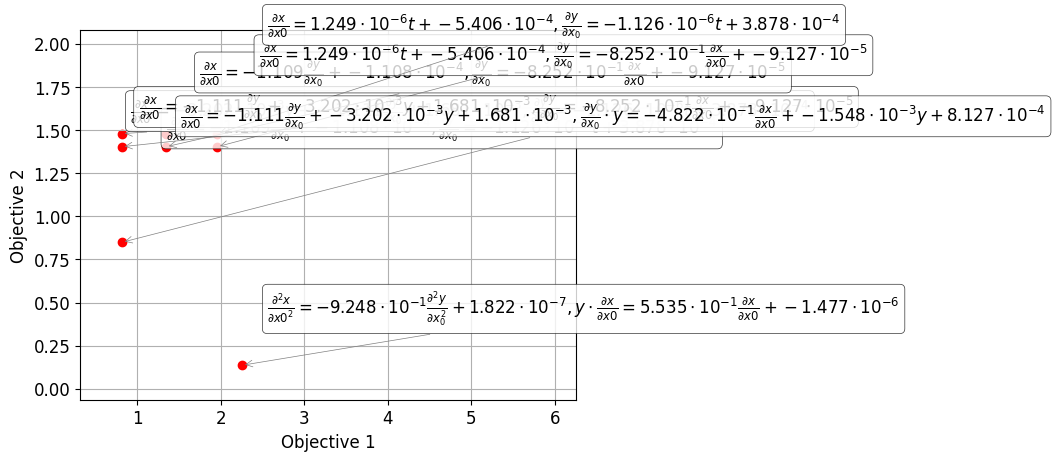

[I 2026-01-16 03:05:17,363] A new study created in memory with name: no-name-dc1c3110-2ea5-4ebb-b54e-b1101a71f45b



System of DE 3 (startpoint 1374-2060):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x334511c50>, <epde.structure.main_structures.SoEq object at 0x3348dd610>, <epde.structure.main_structures.SoEq object at 0x334442810>, <epde.structure.main_structures.SoEq object at 0x3348ff790>, <epde.structure.main_structures.SoEq object at 0x3346808d0>, <epde.structure.main_structures.SoEq object at 0x334d4e390>, <epde.structure.main_structures.SoEq object at 0x3318e8550>, <epde.structure.main_structures.SoEq object at 0x3352e0350>]
Saved: output/robot_32/4_parts/without_force/system_3.csv

--- Optimizing part 4/4 (2061:2750) ---
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x33505d4d0>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x33505d4d0>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 3
Deriv orders after definition [[0], 

[I 2026-01-16 03:05:31,088] Trial 0 finished with value: 4.351150484917083 and parameters: {'poly_window': 11, 'population_size': 6, 'sigma': 50, 'boundary': 7}. Best is trial 0 with value: 4.351150484917083.


During MO : processing 4-th weight.
During MO : processing 5-th weight.
The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x330836350>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x330836350>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [3.14856445e-10 5.29552496e-03]
New solution accepted, confirmed 1/8 solutions.
Creating new equation, sparsity value [1.85515437e-10 3.15044112e-04]
New solution accepted, confirmed 2/

[I 2026-01-16 03:05:54,517] Trial 1 finished with value: 2.8901512586073115 and parameters: {'poly_window': 5, 'population_size': 8, 'sigma': 35, 'boundary': 7}. Best is trial 1 with value: 2.8901512586073115.


...

[I 2026-01-16 03:09:17,227] Trial 18 finished with value: 4.382773006630542 and parameters: {'poly_window': 9, 'population_size': 4, 'sigma': 45, 'boundary': 6}. Best is trial 4 with value: 1.8902801813383403.


The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3351f9dd0>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3351f9dd0>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [6.15984825e-06 5.07155715e-05]
New solution accepted, confirmed 1/4 solutions.
Creating new equation, sparsity value [2.99287001e-08 1.06372166e-04]
New solution accepted, confirmed 2/4 solutions.
Creating new equation, sparsity value [3.19365951e-10 2.706

[I 2026-01-16 03:09:27,538] Trial 19 finished with value: 5.074089834700488 and parameters: {'poly_window': 5, 'population_size': 4, 'sigma': 35, 'boundary': 4}. Best is trial 4 with value: 1.8902801813383403.


The optimization has been conducted.
✅ Trial finish
✅ Part 4: Best params {'poly_window': 7, 'population_size': 5, 'sigma': 65, 'boundary': 7}, score=1.8902801813383403


setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x334911410>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x334911410>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [5.49107518e-08 2.28318906e-10]
New solution accepted, confirmed 1/5 solutions.
Creating new equation, sparsity value [8.94482373e-02 8.65393993e-08]
New solution accepted, confirmed 2/5 solutions.
Creating new equation, sparsity value [2.76311752e-02 8.41312282e-08]
New solution accepted, confirmed 3/5 solu

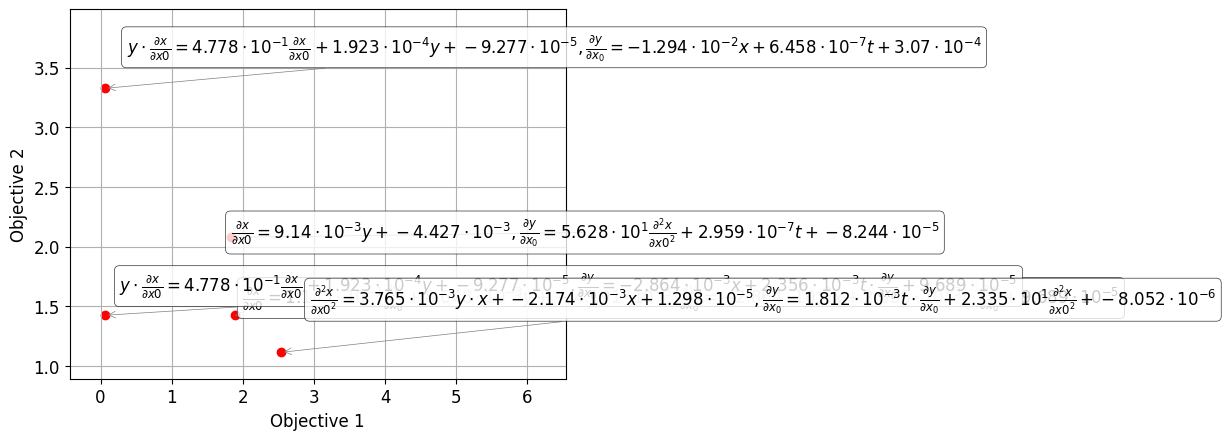


System of DE 4 (startpoint 2061-2749):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x3349e4d10>, <epde.structure.main_structures.SoEq object at 0x334c0d510>, <epde.structure.main_structures.SoEq object at 0x33178f410>, <epde.structure.main_structures.SoEq object at 0x331bf3190>, <epde.structure.main_structures.SoEq object at 0x331702ad0>]
Saved: output/robot_32/4_parts/without_force/system_4.csv
































[I 2026-01-16 03:10:04,886] A new study created in memory with name: no-name-cc06083c-ef9b-4b46-adb9-0adf988da749



 Processing robot 34 with 4 parts...

--- Optimizing part 1/4 (0:687) ---
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x33539f350>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x33539f350>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [1.42886161e-09 3.74727941e-05]
New solution accepted, confirmed 1/6 solutions.
Creating new equation, sparsity value [2.03280268e-01 8.55150459e-09]
New solution accepted, confirmed 2/6 solutions.
Creating new equation, sparsity valu

[I 2026-01-16 03:10:18,157] Trial 0 finished with value: 6.5185259890904295 and parameters: {'poly_window': 11, 'population_size': 6, 'sigma': 40, 'boundary': 6}. Best is trial 0 with value: 6.5185259890904295.


The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31f977450>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31f977450>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [8.54833191e-05 4.32417045e-10]
New solution accepted, confirmed 1/6 solutions.
Creating new equation, sparsity value [4.17941070e-10 5.52165451e-06]
New solution accepted, confirmed 2/6 solutions.
Creating new equation, sparsity value [1.01780904e-08 4.966

...

[I 2026-01-16 03:15:31,938] Trial 18 finished with value: 2.799012453927827 and parameters: {'poly_window': 5, 'population_size': 7, 'sigma': 50, 'boundary': 3}. Best is trial 10 with value: 2.0927908299885094.


During MO : processing 6-th weight.
The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3305b0190>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3305b0190>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [1.81030086e-07 3.86457370e-01]
New solution accepted, confirmed 1/8 solutions.
Creating new equation, sparsity value [1.71648873e-07 9.75675125e-08]
New solution accepted, confirmed 2/8 solutions.
Creating new equation, 

[I 2026-01-16 03:15:57,119] Trial 19 finished with value: 3.0735097157719933 and parameters: {'poly_window': 7, 'population_size': 8, 'sigma': 60, 'boundary': 5}. Best is trial 10 with value: 2.0927908299885094.


During MO : processing 7-th weight.
The optimization has been conducted.
✅ Trial finish
✅ Part 1: Best params {'poly_window': 7, 'population_size': 8, 'sigma': 55, 'boundary': 4}, score=2.0927908299885094


setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x1744b9410>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x1744b9410>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [1.82572502e-03 2.53339057e-07]
New solution accepted, confirmed 1/8 solutions.
Creating new equation, sparsity value [1.53160308e-06 4.83430399e-09]
New solution accepted, confirmed 2/8 solutions.
Creating new equation, sparsity value [2.32135197e-09 1.54914675e-09]
New solution accepted, confirmed 3/8 solu

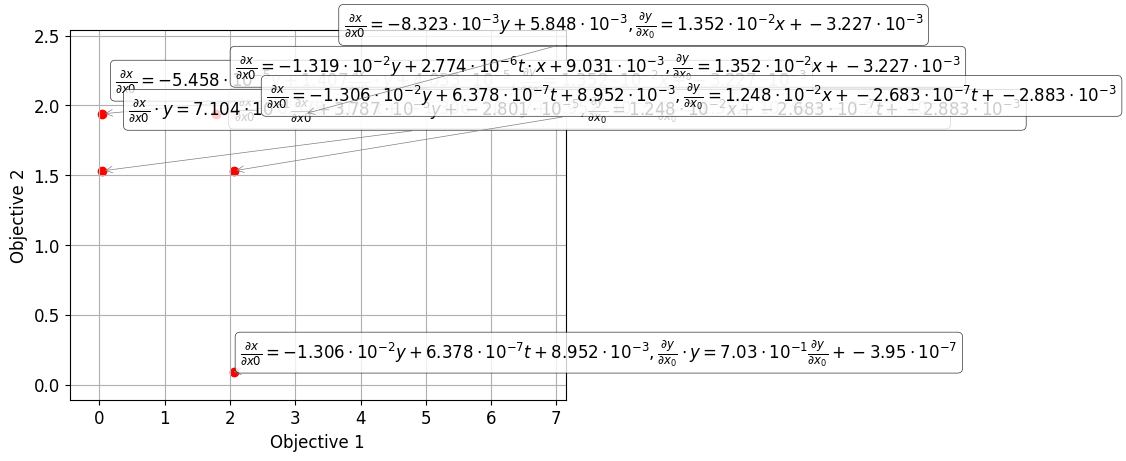

[I 2026-01-16 03:17:55,169] A new study created in memory with name: no-name-a4fef3f8-3eb5-42d7-9cff-db6e1ed21a15



System of DE 1 (startpoint 0-686):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x334969390>, <epde.structure.main_structures.SoEq object at 0x3348688d0>, <epde.structure.main_structures.SoEq object at 0x33471a810>, <epde.structure.main_structures.SoEq object at 0x331c41110>, <epde.structure.main_structures.SoEq object at 0x334b50550>, <epde.structure.main_structures.SoEq object at 0x334b90910>, <epde.structure.main_structures.SoEq object at 0x33115db90>]
EQ 2:
Saved: output/robot_34/4_parts/without_force/system_1.csv

--- Optimizing part 2/4 (687:1374) ---
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31feefd50>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31feefd50>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2

[I 2026-01-16 03:18:06,916] Trial 0 finished with value: 3.0576911490983916 and parameters: {'poly_window': 11, 'population_size': 4, 'sigma': 60, 'boundary': 7}. Best is trial 0 with value: 3.0576911490983916.


The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3401d6d10>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3401d6d10>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [2.29163642e-05 2.44227872e-08]
New solution accepted, confirmed 1/7 solutions.
Creating new equation, sparsity value [1.58971326e-03 1.10311800e-07]
New solution accepted, confirmed 2/7 solutions.
Creating new equation, sparsity value [1.35683389e-06 2.299

[I 2026-01-16 03:18:25,097] Trial 1 finished with value: 4.925270146200398 and parameters: {'poly_window': 11, 'population_size': 7, 'sigma': 50, 'boundary': 7}. Best is trial 0 with value: 3.0576911490983916.


...

[I 2026-01-16 03:24:06,081] Trial 18 finished with value: 6.923836049336429 and parameters: {'poly_window': 7, 'population_size': 6, 'sigma': 40, 'boundary': 4}. Best is trial 9 with value: 2.1781411683333762.


setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x331b6df10>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x331b6df10>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [2.20215723e-09 7.68706456e-09]
New solution accepted, confirmed 1/8 solutions.
Creating new equation, sparsity value [4.11857568e-08 4.39031958e-01]
New solution accepted, confirmed 2/8 solutions.
Creating new equation, sparsity value [5.82552068e-03 2.48100964e-09]
New solution accepted, confirmed 3/8 solu

[I 2026-01-16 03:24:33,330] Trial 19 finished with value: 3.0922537124520053 and parameters: {'poly_window': 9, 'population_size': 8, 'sigma': 60, 'boundary': 6}. Best is trial 9 with value: 2.1781411683333762.


The optimization has been conducted.
✅ Trial finish
✅ Part 2: Best params {'poly_window': 9, 'population_size': 8, 'sigma': 40, 'boundary': 7}, score=2.1781411683333762


setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3439c1410>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3439c1410>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [5.07862864e-10 1.45299382e-07]
New solution accepted, confirmed 1/8 solutions.
Creating new equation, sparsity value [0.00523293 0.03901722]
New solution accepted, confirmed 2/8 solutions.
Creating new equation, sparsity value [0.00847954 0.24821037]
New solution accepted, confirmed 3/8 solutions.
Creating 

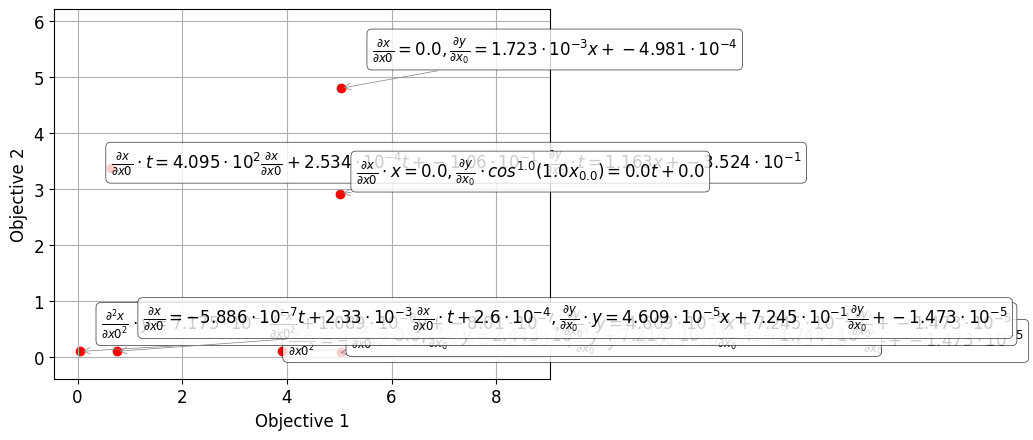

[I 2026-01-16 03:26:35,796] A new study created in memory with name: no-name-2fd17188-9db0-4a7c-8902-66bcc3953193



System of DE 2 (startpoint 687-1373):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x334b6c3d0>, <epde.structure.main_structures.SoEq object at 0x3311ce3d0>, <epde.structure.main_structures.SoEq object at 0x331905990>, <epde.structure.main_structures.SoEq object at 0x33482d650>, <epde.structure.main_structures.SoEq object at 0x3349b3dd0>, <epde.structure.main_structures.SoEq object at 0x334a45590>, <epde.structure.main_structures.SoEq object at 0x3349a80d0>]
EQ 2:
Saved: output/robot_34/4_parts/without_force/system_2.csv

--- Optimizing part 3/4 (1374:2061) ---
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3347a3dd0>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3347a3dd0>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (68

[I 2026-01-16 03:26:46,187] Trial 0 finished with value: 4.630787170672859 and parameters: {'poly_window': 7, 'population_size': 4, 'sigma': 65, 'boundary': 6}. Best is trial 0 with value: 4.630787170672859.


During MO : processing 1-th weight.
During MO : processing 2-th weight.
During MO : processing 3-th weight.
The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31fc72190>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31fc72190>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [1.00490785e-06 1.15818909e-09]
New solution accepted, confirmed 1/8 solutions.
Creating new equation, sparsity value [1.02445631e-06 2.74243985e-09]

[I 2026-01-16 03:27:15,576] Trial 1 finished with value: 0.09361136652363752 and parameters: {'poly_window': 5, 'population_size': 8, 'sigma': 35, 'boundary': 3}. Best is trial 1 with value: 0.09361136652363752.


...

[I 2026-01-16 03:32:39,426] Trial 18 finished with value: 3.331226360790073 and parameters: {'poly_window': 7, 'population_size': 6, 'sigma': 50, 'boundary': 5}. Best is trial 1 with value: 0.09361136652363752.


The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31f406a10>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31f406a10>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [2.63778045e-08 2.96425606e-07]
New solution accepted, confirmed 1/6 solutions.
Creating new equation, sparsity value [1.31224384e-08 1.23252685e-06]
New solution accepted, confirmed 2/6 solutions.
Creating new equation, sparsity value [2.59269794e-04 2.694

[I 2026-01-16 03:32:54,730] Trial 19 finished with value: 4.198913361402529 and parameters: {'poly_window': 9, 'population_size': 6, 'sigma': 45, 'boundary': 7}. Best is trial 1 with value: 0.09361136652363752.


During MO : processing 5-th weight.
The optimization has been conducted.
✅ Trial finish
✅ Part 3: Best params {'poly_window': 5, 'population_size': 8, 'sigma': 35, 'boundary': 3}, score=0.09361136652363752


setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x33137af10>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x33137af10>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [1.39913324e-09 7.19846668e-01]
New solution accepted, confirmed 1/8 solutions.
Creating new equation, sparsity value [0.0025143 0.4227346]
New solution accepted, confirmed 2/8 solutions.
Creating new equation, sparsity value [0.22662106 0.01530384]
New solution accepted, confirmed 3/8 solutions.
Creating ne

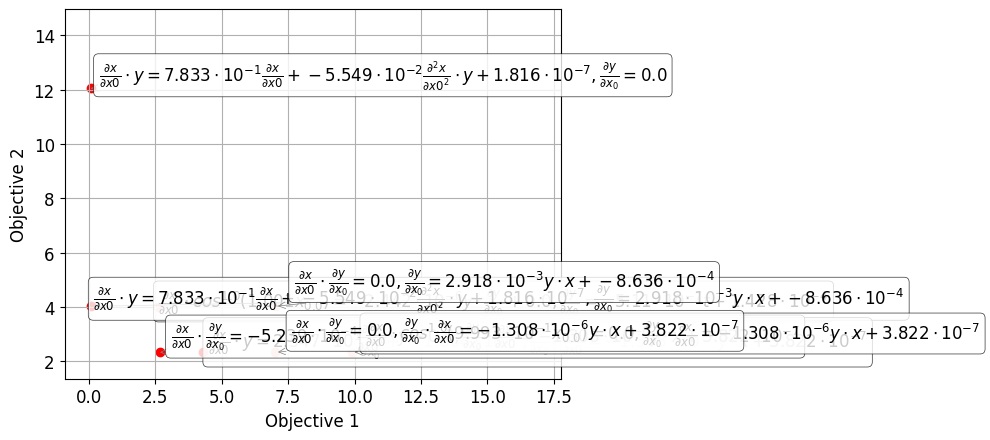

[I 2026-01-16 03:34:36,688] A new study created in memory with name: no-name-4d4ac7b1-0ee3-4bd9-b0d3-0c3552d54ce6



System of DE 3 (startpoint 1374-2060):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x330c64f90>, <epde.structure.main_structures.SoEq object at 0x31fa339d0>, <epde.structure.main_structures.SoEq object at 0x3318da210>, <epde.structure.main_structures.SoEq object at 0x3343d6d50>, <epde.structure.main_structures.SoEq object at 0x331af3ad0>, <epde.structure.main_structures.SoEq object at 0x331b78dd0>, <epde.structure.main_structures.SoEq object at 0x3343a77d0>, <epde.structure.main_structures.SoEq object at 0x334c0dc50>]
Saved: output/robot_34/4_parts/without_force/system_3.csv

--- Optimizing part 4/4 (2061:2750) ---
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x331651410>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x331651410>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 3
Deriv orders after definition [[0], 

[I 2026-01-16 03:35:05,603] Trial 0 finished with value: 5.113713033884153 and parameters: {'poly_window': 5, 'population_size': 8, 'sigma': 45, 'boundary': 4}. Best is trial 0 with value: 5.113713033884153.


During MO : processing 7-th weight.
Restoring containment of x in k_0 x{power: 1.0} + k_1 d^2y/dx0^2{power: 1.0} + k_2 y{power: 1.0} + k_3 = 0.
temp x{power: 1.0} self.main_var_to_explain x
Restoring containment of x in k_0 x{power: 1.0} + k_1 d^2y/dx0^2{power: 1.0} + k_2 y{power: 1.0} + k_3 = 0.
temp x{power: 1.0} self.main_var_to_explain x
Restoring containment of x in k_0 x{power: 1.0} + k_1 d^2y/dx0^2{power: 1.0} + k_2 y{power: 1.0} + k_3 = 0.
The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31f647f10>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31f647f10>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 6
The cardinality of defined token pool is 

[I 2026-01-16 03:35:16,261] Trial 1 finished with value: 6.041677579363437 and parameters: {'poly_window': 5, 'population_size': 4, 'sigma': 35, 'boundary': 5}. Best is trial 0 with value: 5.113713033884153.


...

[I 2026-01-16 03:39:44,743] Trial 18 finished with value: 2.374015295768048 and parameters: {'poly_window': 9, 'population_size': 8, 'sigma': 50, 'boundary': 6}. Best is trial 4 with value: 1.87045813518526.


The optimization has been conducted.
✅ Trial finish
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x33c52a710>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x33c52a710>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [1.76167893e-10 3.26717071e-03]
New solution accepted, confirmed 1/5 solutions.
Creating new equation, sparsity value [5.74616175e-09 8.33057822e-04]
New solution accepted, confirmed 2/5 solutions.
Creating new equation, sparsity value [1.03626851e-06 4.638

[I 2026-01-16 03:39:58,932] Trial 19 finished with value: 4.758122941848555 and parameters: {'poly_window': 11, 'population_size': 5, 'sigma': 55, 'boundary': 7}. Best is trial 4 with value: 1.87045813518526.


During MO : processing 4-th weight.
The optimization has been conducted.
✅ Trial finish
✅ Part 4: Best params {'poly_window': 9, 'population_size': 5, 'sigma': 55, 'boundary': 7}, score=1.87045813518526


setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x33c5c0a10>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x33c5c0a10>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [9.56085722e-01 1.68651879e-10]
New solution accepted, confirmed 1/5 solutions.
Creating new equation, sparsity value [1.47411228e-09 1.21833758e-04]
New solution accepted, confirmed 2/5 solutions.
Creating new equation, sparsity value [0.02774102 0.00369475]
New solution accepted, confirmed 3/5 solutions.
C

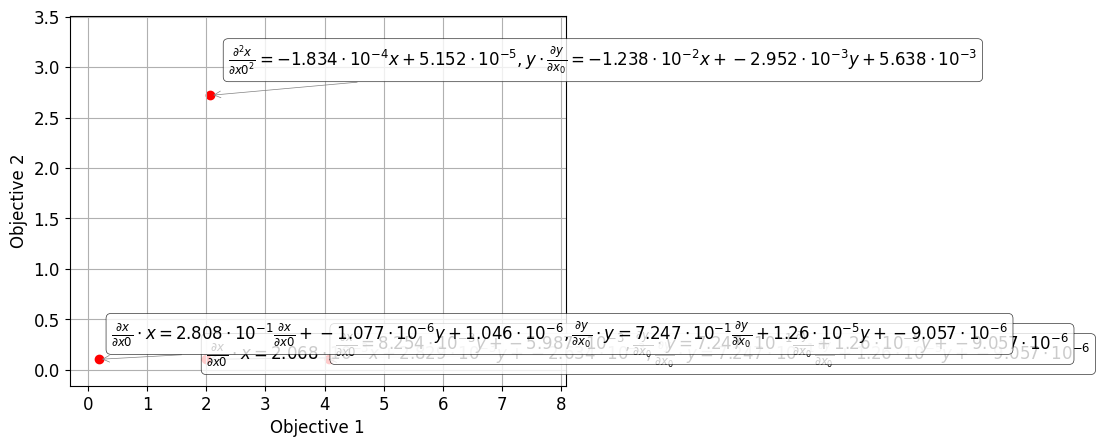


System of DE 4 (startpoint 2061-2749):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x3439b6a10>, <epde.structure.main_structures.SoEq object at 0x330a92590>, <epde.structure.main_structures.SoEq object at 0x334b78a90>, <epde.structure.main_structures.SoEq object at 0x334935110>]
EQ 2:
Saved: output/robot_34/4_parts/without_force/system_4.csv


In [ ]:
# ==========================
# === ROBOT PROCESSING FUNCTION ===
# ==========================
def process_robot(object_id, normalized_coord_data,pwm_signal, force = 'without', num_parts=1, output_dir=Path("output")):
    """Processes robot data, splits into parts, discovers equations, and saves results."""
    print(f"\n Processing robot {object_id} with {num_parts} parts...")

    # === Directories ===
    robot_dir = output_dir / f"robot_{object_id}/{num_parts}_parts/{force}_force"
    robot_dir.mkdir(parents=True, exist_ok=True)

    # === Split data into parts ===
    points = np.array(normalized_coord_data[object_id])
    cut_number = min(2750, len(points))
    cut_points = points[:cut_number]
    part_size = cut_number // num_parts
    boundaries = [i * part_size for i in range(num_parts)] + [cut_number]

    for part_idx in range(num_parts):
        start_idx = boundaries[part_idx]
        end_idx = boundaries[part_idx + 1]
        part_points = cut_points[start_idx:end_idx]
        # pwm_part = np.array(pwm_signal[start_idx:end_idx])
        t_data = np.arange(len(part_points))
        x_data, y_data = part_points[:, 0], part_points[:, 1]
        
        print(f"\n--- Optimizing part {part_idx + 1}/{num_parts} ({start_idx}:{end_idx}) ---")

        # === Objective function for Optuna ===
        def objective(trial):
            poly_window = trial.suggest_int("poly_window", 5, 11, step=2)
            population_size = trial.suggest_int("population_size", 4, 8, step=1)
            sigma = trial.suggest_int("sigma", 35, 65, step=5)
            min_boundary = poly_window // 2 + 1
            max_boundary = 7
            boundary = trial.suggest_int("boundary", min_boundary, max_boundary)

            epde_search_obj_system = EpdeSearch(
            use_solver=False,
            boundary=boundary,
            preprocessor_kwargs={'polynomial_window': poly_window},
            coordinate_tensors=[t_data]
            )
            epde_search_obj_system.set_moeadd_params(population_size=population_size, training_epochs=10)
            epde_search_obj_system.set_preprocessor(
                default_preprocessor_type='poly',
                preprocessor_kwargs={'use_smoothing': True, 'sigma': sigma}
            )
            '''
            external_force_token = CacheStoredTokens(
                token_type='ext_force',
                token_labels=['PWM'],
                token_tensors={'PWM': pwm_part},
                params_ranges={'power': (1, 1)},
                params_equality_ranges=None,
                meaningful=True
            )
            ''' 
            equation_system = EquationDiscoverer([x_data, y_data])
            part_equations = equation_system.discover_system_equation(
                epde_search_obj_system,
                additional_tokens=[],
                dimensionality=0
            )

            values_per_level = [[solution.obj_fun for solution in level] for level in part_equations]
            flat_obj = [vals for level in values_per_level for vals in level]

            best_score = np.inf
            for obj_values in flat_obj:
                score = obj_values[0] + obj_values[1]
                if obj_values[2] + obj_values[3] > 6:
                    score += 100
                best_score = min(best_score, score)
            print(f"✅ Trial finish")
            return best_score

        # === Optuna study ===
        study = optuna.create_study(direction="minimize")
        study.optimize(objective, n_trials=20)
        best_params = study.best_params
        best_score = study.best_value
        print(f"✅ Part {part_idx + 1}: Best params {best_params}, score={best_score}")
        
        fig1 = plot_optimization_history(study)
        fig1.show()
        history_plot_path = robot_dir /f"part_{part_idx + 1}_system_history_plot.html"
        fig1.write_html(history_plot_path)
        fig2 = plot_param_importances(study)
        fig2.show()
        importances_plots_path = robot_dir /f"part_{part_idx + 1}_system_importances_plots.html"
        fig2.write_html(importances_plots_path)

        # === Save plots and params ===
        params_path = robot_dir /f"part_{part_idx + 1}_system_best_params.json"
        with open(params_path, "w") as f:
            json.dump({"best_params": best_params, "score": best_score}, f, indent=4)

        # === Final EPDE system with best params ===
        best_boundary = best_params["boundary"]
        best_window = best_params["poly_window"]
        best_sigma = best_params["sigma"]
        best_population_size = best_params["population_size"]

        epde_search_obj_system = EpdeSearch(
            use_solver=False,
            boundary=best_boundary,
            preprocessor_kwargs={'polynomial_window': best_window},
            coordinate_tensors=[t_data]
        )
        epde_search_obj_system.set_moeadd_params(population_size=best_population_size, training_epochs=50)
        epde_search_obj_system.set_preprocessor(
            default_preprocessor_type='poly',
            preprocessor_kwargs={'use_smoothing': True, 'sigma': best_sigma}
        )
        equation_system = EquationDiscoverer([x_data, y_data])
        part_equations = equation_system.discover_system_equation(
            epde_search_obj_system,
            additional_tokens=[],
            dimensionality=0
        )
        '''
        external_force_token = CacheStoredTokens(
            token_type='ext_force',
            token_labels=['PWM'],
            token_tensors={'PWM': pwm_part},
            params_ranges={'power': (1, 1)},
            params_equality_ranges=None,
            meaningful=True
        )
        pwm_derivs_token = ExternalDerivativesTokens(
            'PWM_derivs',                     # имя токена
            boundary=4,                       # как и у других данных
            time_axis=0,                      # ось времени (0, т.к. одномерная зависимость)
            base_token_label='PWM',           # имя базового токена
            token_tensor=pwm_signal,          # сам сигнал
            max_orders=2,                     # до какой производной считать (1 -> dPWM/dt, 2 -> d²PWM/dt²)
            deriv_method='poly',              # метод вычисления производных
            deriv_method_kwargs={
                'smooth': True,
                'grid': [t_data]
            },
            params_ranges={'power': (1, 1)},  # оставляем без возведения в степень
            params_equality_ranges=None,
            meaningful=True
        )
        '''
        equation_per_level = [
            [[str(eq) for eq in solution.vals] for solution in level] 
            for level in part_equations
        ]
        values_per_level = [
        [solution.obj_fun for solution in level]
                            for level in part_equations]
        for level_idx, level in enumerate(values_per_level):
            print(f"Level {level_idx}:")
            for sol_idx, obj_values in enumerate(level):
                print(f"Solution {sol_idx}: {obj_values}")
        for level_idx, level in enumerate(equation_per_level):
            print(f"Level {level_idx}:")
            for sol_idx, eq_list in enumerate(level):
                print(f"  Solution {sol_idx}:")
                for eq_str in eq_list:
                    print(f"    {eq_str}")
        epde_search_obj_system.visualize_solutions(dimensions=[0,1])
        plt.show()

        # === Process equations into table ===
        equation_processor = EquationProcessor()
        variable_names = ['x', 'y']
        table_main = [{i: [{}, {}]} for i in variable_names]
        k = 0
        vals_flat = []
        for elem in part_equations:
            vals_flat.extend(elem)

        table_main, k = equation_processor.object_table(
            [vals_flat], variable_names, table_main, k, ''
        )
        print(f"\nSystem of DE {part_idx + 1} (startpoint {start_idx}-{end_idx - 1}):")
        for i, eq in enumerate(part_equations):
            print(f"EQ {i + 1}:")
            print(eq)

        # === Save table ===
        frame_main = equation_processor.preprocessing_table(variable_names, table_main, k)
        output_path = robot_dir /f"system_{part_idx + 1}.csv"
        frame_main.to_csv(output_path, sep=',', encoding='utf-8')
        print(f"Saved: {output_path}")
        
# ==========================
# === DISTANCE FUNCTION ===
# ==========================
def find_closest_robots(normalized_coord_data, target_id, n_closest=2):
    """Returns IDs of the n closest robots to the target based on first coordinate."""
    target_coord = normalized_coord_data[target_id][0]
    distances = {
        rid: np.linalg.norm(np.array(coords[0]) - target_coord)
        for rid, coords in normalized_coord_data.items() if rid != target_id
    }
    closest = sorted(distances, key=distances.get)[:n_closest]
    print(f"\n Closest to {target_id}: {closest}")
    return closest

# ==========================
# === MAIN FUNCTION ===
# ==========================
def main(target_robot=78, num_parts=2, n_closest=2):
    with open('data_00_330_[30_bots_PWM_10_15cw_15ccw_D_41cm].MP4.pickle', 'rb') as file:
        raw_data = pickle.load(file)

    processor = DataProcessor(raw_data)
    processor.extract_data()
    pwm_signal = np.array(processor.angle_data[target_robot])
    normalized_coord_data = processor.normalize_all_coordinates()

    robots_to_process = [target_robot]
    if n_closest>0:
        closest = find_closest_robots(normalized_coord_data, target_robot, n_closest)
        robots_to_process += closest

    output_dir = Path("output")
    for rid in robots_to_process:
        process_robot(rid, normalized_coord_data, pwm_signal,num_parts=num_parts, output_dir=output_dir)


if __name__ == "__main__":
    for i in [ 78, 79,  83, 31, 32 , 34]:
        main(target_robot=i, num_parts=4, n_closest=0)


In [ ]:
# ==========================
# === COLLECT SCORES FUNCTION ===
# ==========================
def collect_scores(robot_id=79, root="./output"):
    """Collects all best scores for a robot across parts and forces."""
    root = Path(root)
    scores = []

    for parts_dir in (root / f"robot_{robot_id}").glob("*_parts"):
        n_parts = int(parts_dir.name.split("_")[0])

        for force_dir in parts_dir.glob("*_force"):
            part_scores = []
            for part in range(1, n_parts + 1):
                json_path = force_dir / f"part_{part}_system_best_params.json"
                if not json_path.exists():
                    continue
                with open(json_path, "r") as f:
                    data = json.load(f)
                    score = data.get("score")
                    if score is not None:
                        part_scores.append(score)
            if part_scores:
                avg_score = np.mean(part_scores)
                scores.append({
                    "robot_id": robot_id,
                    "parts_dir": parts_dir.name,
                    "force_dir": force_dir.name,
                    "score": avg_score,
                    "raw_scores": part_scores
                })
    return scores

scores = collect_scores(robot_id=79, root="./output")
scores_sorted = sorted(scores, key=lambda x: (x["parts_dir"], x["force_dir"]))
for s in scores_sorted:
    print(f"Robot {s['robot_id']}, {s['parts_dir']}/{s['force_dir']}: "
          f"score = {s['score']:.5f}, raw scores = {s['raw_scores']}")


Robot 79, 2_parts/without_force: score = 0.25797, raw scores = [0.3576760073279146, 0.15825808675294764]
Robot 79, 4_parts/without_force: score = 0.39153, raw scores = [0.7992378348143865, 0.45043637597957065, 0.16182902947885283, 0.15462449962119434]
Robot 79, 3_parts/without_force: score = 1.72626, raw scores = [2.85775422944278, 0.3562654219715613, 1.964772397721285]
Robot 79, 1_parts/without_force: score = 1.41417, raw scores = [1.4141659411632166]
